# Put/Call Ratio – Optionsmarkt-Sentiment als Frühindikator für ein Ampelsystem

### Eine Hypothesenanalyse auf Basis der Cboe Put/Call Ratios (Equity, Index, Total)

Diese Analyse untersucht, ob die Put/Call Ratio des Optionsmarkts (Verhältnis
gehandelter Put- zu Call-Kontrakte) eigenständige Aussagekraft für die
Rendite- und Risikoentwicklung des S&P 500 besitzt. Die Put/Call Ratio gilt
klassisch als **Kontraindikator**: hohe Werte (viele Puts) deuten auf Angst
bzw. Absicherung hin und gelten historisch eher als bullisches Signal für die
Folgeperiode, niedrige Werte (viele Calls) auf Sorglosigkeit bzw. Übermut und
gelten eher als bearisches Signal. Cboe veröffentlicht drei getrennte
tägliche Reihen: die **Equity-Ratio** (Optionen auf Einzelaktien, überwiegend
Retail-getrieben), die **Index-Ratio** (Optionen auf Indizes, stark durch
institutionelles Hedging geprägt) und die **Total-Ratio** (Kombination
beider). Anders als bei den bisherigen Indikatoren liegen hier zusätzlich
Intraday-Extremwerte (High/Low) vor, nicht nur ein Tagesschlusswert – diese
Analyse nutzt das explizit für eine eigene Hypothese (P8) sowie als
generelle Turbulenzkennzahl.

Ziel ist die Identifikation robuster, statistisch abgesicherter
Frühindikatoren als Bausteine für ein indikatorbasiertes Ampelsystem, das
die aktuelle Marktphase hinsichtlich ihres Rendite- und Risikoprofils
einordnet.

Zehn Hypothesen werden untersucht (P1–P10), gefolgt von einer PCR-basierten
Ampel-Systematik und einer Was-wäre-wenn-Analyse:

**Aufbau:**

1. Datenbezug und Aufbereitung
2. Datenbereinigung und Plausibilisierung
3. Methodik und Hypothesenübersicht
4. Hypothesenanalyse (P1–P10)
5. Einordnung und Handlungsempfehlungen
6. Ampel-Systematik auf Basis der Put/Call Ratio
7. Was-wäre-wenn-Analyse
8. Export der Ergebnisse
9. Zusammenfassung


## 1. Datenbezug und Aufbereitung

### 1.1 Verwendete Bibliotheken

In [1]:
# Numerik, Tabellenverarbeitung und Pfadhandling
import numpy as np
import pandas as pd
from pathlib import Path

# Statistische Tests (Welch-t-Test, Mann-Whitney-U, Kruskal-Wallis) für die
# Gruppen- bzw. Quartilsvergleiche in Abschnitt 3
from scipy import stats
import matplotlib.pyplot as plt

# Einheitliche Farbpalette für sämtliche Diagramme des Notebooks (für
# visuelle Konsistenz im Gesamtprojekt)
COLOR_PRICE = "#0b0b0b"
COLOR_A     = "#2a78d6"
COLOR_B     = "#eb6834"
COLOR_GOOD  = "#0ca30c"
COLOR_WARN  = "#e0a72c"
COLOR_BAD   = "#d03b3b"
COLOR_GRID  = "#e1e0d9"
COLOR_MUTED = "#898781"
COLOR_QUARTILE = ["#f2c6b4", "#eb6834", "#2a78d6", "#123a63"]
# Drei feste Farben je PCR-Reihe (Equity/Index/Total), für Reihenvergleiche
COLOR_SERIE = {"Equity": "#2a78d6", "Index": "#8a3fb0", "Total": "#0b0b0b"}

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "axes.edgecolor": COLOR_MUTED,
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.size": 10,
})

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Bibliotheken geladen.")

Bibliotheken geladen.


### 1.2 Konfiguration

In [2]:
# Zu untersuchender Referenzindex (die Put/Call Ratio ist marktweit, nicht
# indexspezifisch - als Vergleichsindex dient der S&P 500).
INDEX_NAME = "S&P 500"

# Die drei Cboe Put/Call-Ratio-Reihen. Rohdaten: TradingView-Export der
# Symbole USI:PCC (Total), USI:PCCE (Equity), USI:PCCI (Index) - im
# Unterschied zur öffentlichen Cboe-CSV (nur Tagesschlusswert, endet
# 2019-10-04) liefert TradingView täglich fortlaufende OHLC-Werte bis zum
# aktuellen Rand.
PCR_FILES = {
    "Total":  Path("Rohdaten/PCC Equity and Indices.csv"),
    "Equity": Path("Rohdaten/PCCE Equity.csv"),
    "Index":  Path("Rohdaten/PCCI Indices.csv"),
}
PCR_SERIES = list(PCR_FILES.keys())

# Kursdaten inkl. bereits berechneter Wochenbasis-SMA und Vorwärts-
# Zielgrößen (fwd_return/fwd_mdd) für die Horizonte 30/60/90 Handelstage.
PRICE_FILE = Path("../data/S&P_500_clean_with_sma.csv")

# Analysezeitraum: wird in Abschnitt 2.1 anhand der tatsächlichen
# Datenverfügbarkeit aller drei Reihen empirisch bestimmt.
START_DATE_ANALYSE = None  # Platzhalter, siehe 2.1/2.2

# Glättungsfenster der täglichen PCR (Handelstage) - reduziert das
# Tagesrauschen der Rohreihe. 5 = ca. 1 Handelswoche, 10 = ca. 2 Wochen
# (Standardfenster in der gängigen Sentiment-Literatur), 21 = ca. 1 Monat.
PCR_MA_FENSTER = [5, 10, 21]
PCR_FENSTER_REGIME = 10   # Hauptfenster für P1-P3, P6, P9 (2 Handelswochen)
PCR_FENSTER_FAST = 5      # schnelles Fenster für P4/P5 (Ausbruchserkennung)
PCR_FENSTER_SLOW = 21     # träges Fenster für P4/P5 (Basisregime)

# Zeitfenster für die Trend-Divergenz-Hypothese P10 (Handelstage):
# 10 = 2 Wochen, 21 = 1 Monat, 63 = 1 Quartal.
TREND_DIVERGENZ_FENSTER = [10, 21, 63]

# Feste (empirische) Dezil-/Quartilsgrenzen werden je Reihe aus der
# jeweiligen Verteilung selbst abgeleitet (siehe 3.1), da sich die
# Wertebereiche der drei Reihen stark unterscheiden (Equity im Mittel ~0.6,
# Index strukturell höher durch institutionelles Hedging).
QUARTIL_LABELS = ["Q1 (niedrigste PCR)", "Q2", "Q3", "Q4 (höchste PCR)"]

# Prognosehorizonte in Handelstagen (identisch zu den bereits vorliegenden
# fwd_return_*/fwd_mdd_*-Spalten der Kursdaten)
HORIZONS = [30, 60, 90]

# Zielordner für den Export der Ergebnistabellen (Abschnitt 8)
EXPORT_DIR = Path("Hypothesenanalysen")
EXPORT_DIR.mkdir(exist_ok=True)

print(f"Untersuchte PCR-Reihen: {PCR_SERIES}")
print(f"Referenzindex: {INDEX_NAME}")
print(f"Glättungsfenster: {PCR_MA_FENSTER}")
print(f"Ergebnisordner: {EXPORT_DIR.resolve()}")

Untersuchte PCR-Reihen: ['Total', 'Equity', 'Index']
Referenzindex: S&P 500
Glättungsfenster: [5, 10, 21]
Ergebnisordner: C:\Users\ramos\OneDrive\Privat\Data Science Institute\Abschlussprojekt\Put Call Ratio\Hypothesenanalysen


### 1.3 Put/Call-Ratio-Datenbezug

In [3]:
def lade_pcr(pfad: Path, reihe: str) -> pd.DataFrame:
    '''Lädt einen TradingView-OHLC-Export einer Put/Call-Ratio-Reihe.
    Die vier EMA-Spalten des Exports werden nicht übernommen: Ihre
    Glättungsperioden sind im Export nicht benannt (vier gleich benannte
    "EMA"-Spalten) und damit nicht reproduzierbar dokumentierbar - eigene,
    klar benannte gleitende Durchschnitte werden stattdessen in Abschnitt
    2.5 berechnet.'''
    rohdaten = pd.read_csv(pfad, parse_dates=["time"])
    df = rohdaten[["time", "open", "high", "low", "close"]].copy()
    df = df.set_index("time")
    df.index.name = "Date"
    df.columns = [f"{reihe}_{c}" for c in df.columns]
    return df


pcr_rohdaten = {reihe: lade_pcr(pfad, reihe) for reihe, pfad in PCR_FILES.items()}
for reihe, d in pcr_rohdaten.items():
    print(f"{reihe}: {len(d):,} Zeilen, Zeitraum {d.index.min().date()} bis "
          f"{d.index.max().date()}, Close-Wertebereich {d[f'{reihe}_close'].min():.3f} "
          f"bis {d[f'{reihe}_close'].max():.3f}")

Total: 4,982 Zeilen, Zeitraum 2006-10-17 bis 2026-08-11, Close-Wertebereich 0.558 bis 3.148
Equity: 4,918 Zeilen, Zeitraum 2007-01-23 bis 2026-08-11, Close-Wertebereich 0.000 bis 3.148
Index: 4,900 Zeilen, Zeitraum 2007-01-23 bis 2026-08-11, Close-Wertebereich 0.000 bis 4.005


### 1.4 Kursdatenbezug

In [4]:
def lade_kursdaten(pfad: Path) -> pd.DataFrame:
    '''Lädt die bereits bereinigten Kurs- und SMA-Daten des Index
    (Date, Close, wöchentliche SMA sowie Vorwärts-Zielgrößen für
    30/60/90 Handelstage).'''
    df = pd.read_csv(pfad, parse_dates=["Date"], index_col="Date")
    return df


preis_df = lade_kursdaten(PRICE_FILE)
print(f"Kursdaten: {len(preis_df):,} Zeilen, Zeitraum {preis_df.index.min().date()} bis "
      f"{preis_df.index.max().date()}")
preis_df[["Close"] + [f"fwd_return_{h}d" for h in HORIZONS]].tail()

Kursdaten: 4,930 Zeilen, Zeitraum 2007-01-03 bis 2026-08-07


,Close,fwd_return_30d,fwd_return_60d,fwd_return_90d
Date,,,,
2026-08-03,"7,600.5000",NaN,NaN,NaN
2026-08-04,"7,736.5200",NaN,NaN,NaN
2026-08-05,"7,723.5498",NaN,NaN,NaN
2026-08-06,"7,709.9600",NaN,NaN,NaN
2026-08-07,"7,757.6401",NaN,NaN,NaN


## 2. Datenbereinigung und Plausibilisierung

### 2.1 Datenqualitätsprüfung

In [5]:
def pcr_qualität_report(d: pd.DataFrame, reihe: str) -> dict:
    close = d[f"{reihe}_close"]
    high = d[f"{reihe}_high"]
    low = d[f"{reihe}_low"]
    gap_days = d.index.to_series().diff().dt.days
    return {
        "Anzahl Zeilen": len(d),
        "Duplizierte Datums-Indizes": int(d.index.duplicated().sum()),
        "Fehlende Werte (close)": int(close.isna().sum()),
        "Negative Werte": int((d[[f"{reihe}_open", f"{reihe}_high", f"{reihe}_low", f"{reihe}_close"]] < 0).sum().sum()),
        "High < Low (unplausibel)": int((high < low).sum()),
        "Close außerhalb [Low, High]": int(((close > high) | (close < low)).sum()),
        "Nullwerte (close <= 0, technischer Datenausfall)": int((close <= 0).sum()),
        "Größte Datenlücke (Kalendertage)": float(gap_days.max()) if len(gap_days.dropna()) else np.nan,
        "Anteil Lücken > 10 Kalendertage": float((gap_days > 10).mean()),
        "Extremwerte (close > 3)": int((close > 3).sum()),
    }


print("--- Datenqualitätsbericht je Put/Call-Ratio-Reihe (Rohdaten) ---")
for reihe, d in pcr_rohdaten.items():
    print(f"\n{reihe}:")
    for k, v in pcr_qualität_report(d, reihe).items():
        print(f"  {k:.<48s} {v}")

--- Datenqualitätsbericht je Put/Call-Ratio-Reihe (Rohdaten) ---

Total:
  Anzahl Zeilen................................... 4982
  Duplizierte Datums-Indizes...................... 0
  Fehlende Werte (close).......................... 0
  Negative Werte.................................. 0
  High < Low (unplausibel)........................ 0
  Close außerhalb [Low, High]..................... 0
  Nullwerte (close <= 0, technischer Datenausfall) 0
  Größte Datenlücke (Kalendertage)................ 5.0
  Anteil Lücken > 10 Kalendertage................. 0.0
  Extremwerte (close > 3)......................... 2

Equity:
  Anzahl Zeilen................................... 4918
  Duplizierte Datums-Indizes...................... 0
  Fehlende Werte (close).......................... 0
  Negative Werte.................................. 0
  High < Low (unplausibel)........................ 0
  Close außerhalb [Low, High]..................... 0
  Nullwerte (close <= 0, technischer Datenausfall) 2
  Größt

**Befund:** Alle drei Reihen sind durchgehend ohne Duplikate und ohne
unplausible OHLC-Kombinationen (High < Low bzw. Close außerhalb der
Tagesspanne kommt nicht vor). Drei Handelstage weisen jedoch einen
technischen Datenausfall auf (OHLC = 0.0, ein am Optionsmarkt nicht
realistischer Wert): 06.08.2018 bei der Index-Reihe sowie 18.06.2026 und
02.07.2026 bei der Equity-Reihe - vermutlich ein Exportfehler der
TradingView-Quelle an diesen Tagen. Diese drei Zeilen werden in Abschnitt
2.2 auf NaN gesetzt und anschließend wie reguläre Lücken behandelt (siehe
unten), statt als reale Extremwerte in die Analyse einzugehen. Die
Total-Reihe beginnt am 17.10.2006, die Equity- und Index-Reihe erst am
23.01.2007 - der gemeinsame Analysezeitraum wird daher unten einheitlich auf
den späteren der beiden Startpunkte begrenzt. Die übrigen Extremwerte
(Close > 3, insbesondere Anfang 2010 und 2007) sind dagegen plausible
Ausschläge während realer Marktstressphasen und werden nicht als
Datenfehler behandelt.

### 2.2 Bereinigungsschritte

In [6]:
def bereinige_pcr(d: pd.DataFrame, reihe: str) -> pd.DataFrame:
    bereinigt = d[~d.index.duplicated(keep="first")].sort_index()
    # Technischer Datenausfall (OHLC = 0.0, siehe 2.1) wird auf NaN gesetzt
    # und damit wie eine fehlende Beobachtung behandelt statt als realer
    # (und am Optionsmarkt unmöglicher) Extremwert von 0.
    ausfall = bereinigt[f"{reihe}_close"] <= 0
    bereinigt.loc[ausfall, [f"{reihe}_open", f"{reihe}_high", f"{reihe}_low", f"{reihe}_close"]] = np.nan
    return bereinigt


pcr_bereinigt = {reihe: bereinige_pcr(d, reihe) for reihe, d in pcr_rohdaten.items()}

# Gemeinsamer Startpunkt: der spätere der drei Reihenstarts.
START_DATE_ANALYSE = max(d.index.min() for d in pcr_bereinigt.values())
pcr_bereinigt = {reihe: d.loc[d.index >= START_DATE_ANALYSE] for reihe, d in pcr_bereinigt.items()}

# Zusammenführung der drei Reihen zu einer gemeinsamen Tabelle.
pcr_df = pd.concat(pcr_bereinigt.values(), axis=1)
print(f"Analysebeginn (spätester gemeinsamer Reihenstart): {START_DATE_ANALYSE.date()}")
print(f"Put/Call-Ratio (alle Reihen gemeinsam) nach Bereinigung: {len(pcr_df):,} Zeilen "
      f"({pcr_df.index.min().date()} bis {pcr_df.index.max().date()})")

n_unvollständig = int(pcr_df.isna().any(axis=1).sum())
print(f"Handelstage mit mindestens einem fehlenden PCR-Wert: {n_unvollständig} "
      f"({n_unvollständig / len(pcr_df):.1%})")
pcr_df = pcr_df.dropna()

Analysebeginn (spätester gemeinsamer Reihenstart): 2007-01-23
Put/Call-Ratio (alle Reihen gemeinsam) nach Bereinigung: 4,918 Zeilen (2007-01-23 bis 2026-08-11)
Handelstage mit mindestens einem fehlenden PCR-Wert: 21 (0.4%)


### 2.3 Zusammenführung mit den Kursdaten

In [7]:
# Innerer Verbund über den Handelskalender: TradingView (PCR) und Yahoo
# Finance (Kurs) weichen an einzelnen Tagen leicht voneinander ab - nur
# Handelstage, die in beiden Quellen vorhanden sind, gehen in die Analyse ein.
df = pcr_df.join(preis_df, how="inner")
df = df.loc[df.index >= START_DATE_ANALYSE].copy()

anteil_verworfen_pcr = 1 - len(df) / len(pcr_df)
print(f"Gemeinsamer Datensatz: {len(df):,} Handelstage "
      f"({df.index.min().date()} bis {df.index.max().date()})")
print(f"Davon durch den Kalenderabgleich verworfene PCR-Handelstage: {anteil_verworfen_pcr:.2%}")
df[[f"{r}_close" for r in PCR_SERIES] + ["Close"]].describe()

Gemeinsamer Datensatz: 4,894 Handelstage (2007-01-23 bis 2026-08-07)
Davon durch den Kalenderabgleich verworfene PCR-Handelstage: 0.06%


,Total_close,Equity_close,Index_close,Close
count,"4,894.0000","4,894.0000","4,894.0000","4,894.0000"
mean,0.9413,0.8201,1.1930,"2,814.0935"
std,0.1514,0.1825,0.3105,"1,673.0984"
min,0.5580,0.4200,0.3550,676.5300
25%,0.8390,0.6925,0.9962,"1,424.7500"
50%,0.9220,0.7990,1.1429,"2,181.0950"
75%,1.0220,0.9170,1.3470,"3,966.8476"
max,1.9468,2.4583,4.0050,"7,757.6401"


### 2.4 Wöchentlicher Indextrend

In [8]:
# Wöchentlicher Trend des Index: positiv, wenn der Kurs über seiner
# wöchentlichen SMA50 (ca. ein Jahr) notiert.
wochenschluss_trend = preis_df["Close"].resample("W-FRI").last().dropna()
sma50_wochenbasis = wochenschluss_trend.rolling(window=50, min_periods=50).mean().rename("SMA50_w")
mapping_sma50_w = pd.merge_asof(
    df.reset_index()[["Date"]], sma50_wochenbasis.reset_index(), on="Date", direction="backward",
)
df["SMA50_w"] = mapping_sma50_w["SMA50_w"].values

valide_trend = df["SMA50_w"].notna()
df["Wochentrend_positiv"] = np.where(valide_trend, df["Close"] > df["SMA50_w"], np.nan)

verteilung = df["Wochentrend_positiv"].value_counts(dropna=False)
print("Verteilung des wöchentlichen Trends (1.0 = positiv, 0.0 = negativ, NaN = kein SMA50_w):")
print(verteilung)

Verteilung des wöchentlichen Trends (1.0 = positiv, 0.0 = negativ, NaN = kein SMA50_w):
Wochentrend_positiv
1.0000    3595
0.0000    1072
NaN        227
Name: count, dtype: int64


### 2.5 Glättung und abgeleitete Kennzahlen

In [9]:
# Gleitende Durchschnitte je PCR-Reihe und Fenster (reduzieren das
# Tagesrauschen der Rohreihe, siehe 1.2) sowie die tägliche Intraday-Spanne
# (High - Low) relativ zum Schlusswert als Turbulenzkennzahl des
# Optionsmarkts selbst.
for reihe in PCR_SERIES:
    for fenster in PCR_MA_FENSTER:
        df[f"{reihe}_ma{fenster}"] = df[f"{reihe}_close"].rolling(fenster, min_periods=fenster).mean()
    df[f"{reihe}_spanne_rel"] = (df[f"{reihe}_high"] - df[f"{reihe}_low"]) / df[f"{reihe}_close"]

print("Beispiel abgeleiteter Spalten (Equity-Reihe):")
df[[f"Equity_close", "Equity_ma5", "Equity_ma10", "Equity_ma21", "Equity_spanne_rel"]].tail()

Beispiel abgeleiteter Spalten (Equity-Reihe):


,Equity_close,Equity_ma5,Equity_ma10,Equity_ma21,Equity_spanne_rel
Date,,,,,
2026-08-03,0.6999,0.8098,0.8328,0.8000,0.1213
2026-08-04,0.6107,0.7724,0.8133,0.7979,0.2203
2026-08-05,0.7468,0.7488,0.8034,0.7976,0.2908
2026-08-06,0.7343,0.7377,0.7887,0.7942,0.1383
2026-08-07,0.6414,0.6866,0.7616,0.7900,0.2691


### 2.6 Zielgrößen

In [10]:
# Die Vorwärts-Zielgrößen (Rendite und maximaler Rücklauf über 30/60/90
# Handelstage) sind bereits im Kursdatensatz enthalten und werden unverändert
# übernommen.
zielgrößen_spalten = [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]
df[zielgrößen_spalten].describe()

,fwd_return_30d,fwd_return_60d,fwd_return_90d,fwd_mdd_30d,fwd_mdd_60d,fwd_mdd_90d
count,"4,865.0000","4,836.0000","4,806.0000","4,865.0000","4,836.0000","4,806.0000"
mean,0.0117,0.0237,0.0354,-0.0514,-0.0757,-0.0934
std,0.0561,0.0765,0.0934,0.0462,0.0623,0.0727
min,-0.3276,-0.4129,-0.3958,-0.3392,-0.4215,-0.4236
25%,-0.0127,-0.0090,-0.0074,-0.0639,-0.0943,-0.1028
50%,0.0181,0.0347,0.0478,-0.0390,-0.0569,-0.0720
75%,0.0441,0.0687,0.0907,-0.0221,-0.0388,-0.0476
max,0.2820,0.3916,0.4509,-0.0039,-0.0076,-0.0115


## 3. Methodik und Hypothesenübersicht

### 3.1 Statistisches Prüfverfahren

In [11]:
def vergleiche_gruppen(gruppe_a: pd.Series, gruppe_b: pd.Series,
                        label_a: str = "Gruppe A", label_b: str = "Gruppe B") -> dict | None:
    a = gruppe_a.dropna()
    b = gruppe_b.dropna()

    # Mindeststichprobe je Gruppe, unterhalb derer ein Test nicht als
    # belastbar gilt - Vergleich wird in diesem Fall übersprungen (None).
    if len(a) < 10 or len(b) < 10:
        return None

    # Welch-t-Test (robust bei ungleicher Varianz) und Mann-Whitney-U-Test
    # (verteilungsfrei) parallel geprüft; als "signifikant" gilt nur ein
    # Ergebnis, das in beiden Tests unter 5 % liegt.
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")

    return {
        "label_a": label_a, "n_a": len(a), "mean_a": a.mean(), "median_a": a.median(), "std_a": a.std(),
        "label_b": label_b, "n_b": len(b), "mean_b": b.mean(), "median_b": b.median(), "std_b": b.std(),
        "t_pvalue": t_p, "u_pvalue": u_p,
        "signifikant_5pct": bool(t_p < 0.05 and u_p < 0.05),
    }


def vergleiche_quartile(gruppen: dict[str, pd.Series]) -> dict | None:
    '''Omnibus-Vergleich über alle vier Quartile per Kruskal-Wallis-Test,
    ergänzt um den paarweisen Extremvergleich Q1 vs. Q4 mit
    vergleiche_gruppen(). Bei Mehrfachvergleichen ist die Gefahr eines
    zufälligen Treffers höher als bei einem Einzeltest - die Ergebnisse
    sind daher im Zusammenhang der gesamten Tabelle zu interpretieren.'''
    bereinigt = {k: v.dropna() for k, v in gruppen.items()}
    if any(len(v) < 10 for v in bereinigt.values()):
        return None

    h_stat, h_p = stats.kruskal(*bereinigt.values())
    q1_vs_q4 = vergleiche_gruppen(bereinigt[QUARTIL_LABELS[0]], bereinigt[QUARTIL_LABELS[3]],
                                   QUARTIL_LABELS[0], QUARTIL_LABELS[3])

    ergebnis = {
        "kw_pvalue": h_p,
        "kw_signifikant_5pct": bool(h_p < 0.05),
    }
    for label in QUARTIL_LABELS:
        ergebnis[f"mean_{label}"] = bereinigt[label].mean()
        ergebnis[f"n_{label}"] = len(bereinigt[label])
    if q1_vs_q4:
        ergebnis["q1_vs_q4_t_pvalue"] = q1_vs_q4["t_pvalue"]
        ergebnis["q1_vs_q4_u_pvalue"] = q1_vs_q4["u_pvalue"]
        ergebnis["q1_vs_q4_signifikant_5pct"] = q1_vs_q4["signifikant_5pct"]
    return ergebnis


def ereignis_hypothese(event: pd.Series, label: str, extra: dict) -> tuple[list[dict], pd.DataFrame | None]:
    '''Testet ein Ereignis (event=True an den Signaltagen) gegen die
    Basisrate aller Handelstage. Liefert (Ergebnisliste, None) bei
    ausreichender Stichprobe (>= 10 Ereignisse), sonst (leere Liste, Tabelle
    der Einzelereignisse) zur deskriptiven Auflistung.'''
    n = int(event.sum())
    if n >= 10:
        ergebnisse = []
        for h in HORIZONS:
            for ziel in ["fwd_return", "fwd_mdd"]:
                res = vergleiche_gruppen(
                    df.loc[event, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
                    label_a=label, label_b="Basisrate (alle Tage)",
                )
                if res:
                    res.update({**extra, "horizont_tage": h, "zielgröße": ziel, "n_events": n})
                    ergebnisse.append(res)
        return ergebnisse, None
    else:
        spalten = [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]
        einzel = df.loc[event, spalten].reset_index()
        for k, v in extra.items():
            einzel[k] = v
        return [], einzel


def ergebnisse_zu_tabelle(ergebnisse: list[dict]) -> pd.DataFrame:
    return pd.DataFrame(ergebnisse)


alle_ergebnisse: dict[str, pd.DataFrame] = {}
print("Statistisches Prüfverfahren definiert.")

Statistisches Prüfverfahren definiert.


### 3.2 Grafische Auswertung

In [12]:
def plotte_gruppenvergleich(tabelle: pd.DataFrame, titel: str) -> None:
    fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
    for achse, ziel, beschriftung in zip(achsen, ["fwd_return", "fwd_mdd"],
                                          ["\u00d8 Vorwärtsrendite", "\u00d8 maximaler Rücklauf (Drawdown)"]):
        teil = tabelle[tabelle["zielgröße"] == ziel]
        if len(teil) == 0:
            continue
        x = np.arange(len(teil))
        breite = 0.35
        achse.bar(x - breite / 2, teil["mean_a"] * 100, breite, label=teil["label_a"].iloc[0], color=COLOR_A)
        achse.bar(x + breite / 2, teil["mean_b"] * 100, breite, label=teil["label_b"].iloc[0], color=COLOR_B)
        achse.set_xticks(x)
        achse.set_xticklabels([f"{h}d" for h in teil["horizont_tage"]])
        achse.set_ylabel(f"{beschriftung} (%)")
        achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
        achse.legend(fontsize=8)
    fig.suptitle(titel)
    fig.tight_layout()
    plt.show()


def plotte_quartile(tabelle_quartile: pd.DataFrame, horizont: int, titel: str) -> None:
    zeile = tabelle_quartile[tabelle_quartile["horizont_tage"] == horizont].iloc[0]
    fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
    for achse, ziel_prefix, beschriftung in zip(
        achsen, ["fwd_return", "fwd_mdd"], ["\u00d8 Vorwärtsrendite", "\u00d8 maximaler Rücklauf (Drawdown)"]
    ):
        werte = [zeile.get(f"mean_{label}") for label in QUARTIL_LABELS]
        achse.bar(QUARTIL_LABELS, [w * 100 if w is not None else np.nan for w in werte], color=COLOR_QUARTILE)
        achse.set_ylabel(f"{beschriftung} {horizont}d (%)")
        achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
        plt.setp(achse.get_xticklabels(), rotation=15, ha="right")
    fig.suptitle(titel)
    fig.tight_layout()
    plt.show()


print("Funktionen zur grafischen Auswertung definiert.")

Funktionen zur grafischen Auswertung definiert.


### 3.3 Untersuchte Hypothesen

| # | Hypothese | Typ |
|---|---|---|
| P1 | Extremregime: oberstes vs. unterstes Dezil der 10-Tage-PCR, je Reihe (Kontraindikator) | Zustand |
| P2 | Richtung der 10-Tage-PCR: steigend vs. fallend, je Reihe | Zustand |
| P3 | PCR in Quartilen (10-Tage-Durchschnitt), je Reihe | Zustand |
| P4 | Frühindikator Angst-Spitze: Ausbruch aus ruhiger Zone ins obere Dezil, je Reihe | Ereignis (selten) |
| P5 | Frühindikator Sorglosigkeits-Spitze: Spiegelbild von P4, je Reihe | Ereignis (selten) |
| P6 | Divergenz Equity- vs. Index-PCR (Retail- vs. institutionelles Sentiment) | Ereignis |
| P7 | Wochentrend + PCR-Extrem kombiniert, je Reihe | Ereignis |
| P8 | Intraday-Spike vs. Close-Bestätigung (High/Low-basiert), je Reihe | Zustand |
| P9 | PCR Thrust/Collapse: schneller Wechsel zwischen 5- und 21-Tage-PCR, je Reihe | Ereignis (selten) |
| P10 | Trend-Divergenz Kurs vs. PCR über mehrere Zeitfenster, je Reihe | Zustand |

P1-P3, P8 und P10 sind Zustandsgrößen mit tausenden bzw. hunderten
Beobachtungstagen je Gruppe und liefern damit die statistisch robusteste
Grundlage. P4, P5, P6, P7 und P9 sind demgegenüber Ereignishypothesen mit
potenziell wenigen historischen Vorkommen: Ergebnisse mit weniger als 10
Ereignissen je Gruppe werden rein deskriptiv (Tabelle der Einzelereignisse)
statt mit Signifikanztest ausgewiesen.

## 4. Hypothesenanalyse

### 4.1 P1 - PCR-Extremregime (Dezil-basiert, Kontraindikator)

**Hypothese:** Notiert die 10-Tage-PCR im obersten Dezil ihrer eigenen
historischen Verteilung (starke Put-Nachfrage/Angst), unterscheidet sich die
Folgeperiode des S&P 500 von Tagen im untersten Dezil (starke
Call-Nachfrage/Sorglosigkeit). Als Kontraindikator gelesen wird erwartet,
dass das obere Dezil (Angst) mit einer günstigeren, das untere Dezil
(Sorglosigkeit) mit einer ungünstigeren Folgeperiode einhergeht.

In [13]:
def pcr_extremregime(reihe: str, fenster: int = PCR_FENSTER_REGIME) -> tuple[pd.Series, pd.Series]:
    ma = df[f"{reihe}_ma{fenster}"]
    p10, p90 = ma.quantile([0.10, 0.90])
    oberes_dezil = ma >= p90
    unteres_dezil = ma <= p10
    return oberes_dezil, unteres_dezil


ergebnisse_p1 = []
for reihe in PCR_SERIES:
    oben, unten = pcr_extremregime(reihe)
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[oben, f"{ziel}_{h}d"], df.loc[unten, f"{ziel}_{h}d"],
                label_a=f"{reihe}-PCR oberstes Dezil (Angst)", label_b=f"{reihe}-PCR unterstes Dezil (Sorglosigkeit)",
            )
            if res:
                res.update({"reihe": reihe, "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_p1.append(res)

tabelle_p1 = ergebnisse_zu_tabelle(ergebnisse_p1)
alle_ergebnisse["P1_PCR_Extremregime"] = tabelle_p1
spalten_anzeige = ["reihe", "horizont_tage", "zielgröße", "label_a", "mean_a", "label_b", "mean_b",
                    "t_pvalue", "u_pvalue", "signifikant_5pct"]
tabelle_p1[spalten_anzeige]

,reihe,horizont_tage,zielgröße,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Total,30,fwd_return,Total-PCR oberstes Dezil (Angst),0.0262,Total-PCR unterstes Dezil (Sorglosigkeit),0.0136,0.0009,0.0000,True
1,Total,30,fwd_mdd,Total-PCR oberstes Dezil (Angst),-0.0660,Total-PCR unterstes Dezil (Sorglosigkeit),-0.0492,0.0000,0.0000,True
2,Total,60,fwd_return,Total-PCR oberstes Dezil (Angst),0.0446,Total-PCR unterstes Dezil (Sorglosigkeit),0.0357,0.0548,0.0063,False
3,Total,60,fwd_mdd,Total-PCR oberstes Dezil (Angst),-0.0887,Total-PCR unterstes Dezil (Sorglosigkeit),-0.0704,0.0000,0.0000,True
4,Total,90,fwd_return,Total-PCR oberstes Dezil (Angst),0.0546,Total-PCR unterstes Dezil (Sorglosigkeit),0.0597,0.3960,0.8080,False
5,Total,90,fwd_mdd,Total-PCR oberstes Dezil (Angst),-0.1032,Total-PCR unterstes Dezil (Sorglosigkeit),-0.0788,0.0000,0.0000,True
6,Equity,30,fwd_return,Equity-PCR oberstes Dezil (Angst),0.0340,Equity-PCR unterstes Dezil (Sorglosigkeit),0.0085,0.0000,0.0000,True
7,Equity,30,fwd_mdd,Equity-PCR oberstes Dezil (Angst),-0.0511,Equity-PCR unterstes Dezil (Sorglosigkeit),-0.0497,0.5298,0.6471,False
8,Equity,60,fwd_return,Equity-PCR oberstes Dezil (Angst),0.0582,Equity-PCR unterstes Dezil (Sorglosigkeit),0.0208,0.0000,0.0000,True
9,Equity,60,fwd_mdd,Equity-PCR oberstes Dezil (Angst),-0.0692,Equity-PCR unterstes Dezil (Sorglosigkeit),-0.0749,0.0564,0.0310,False


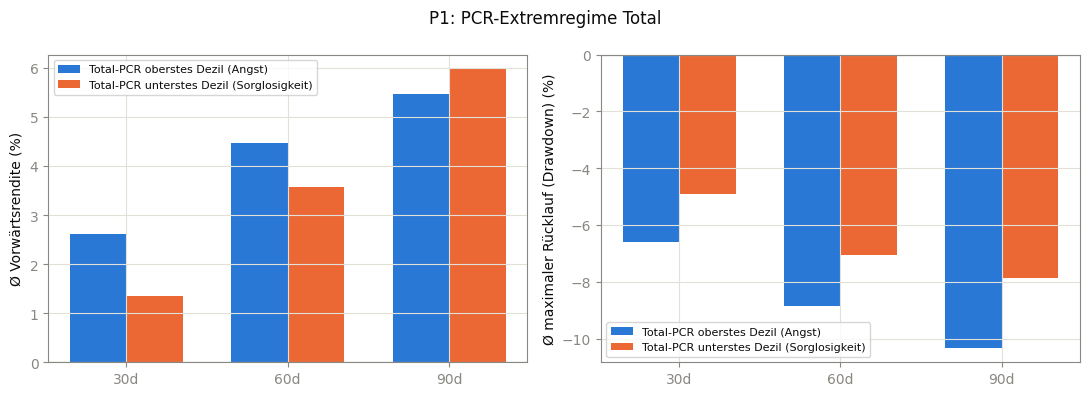

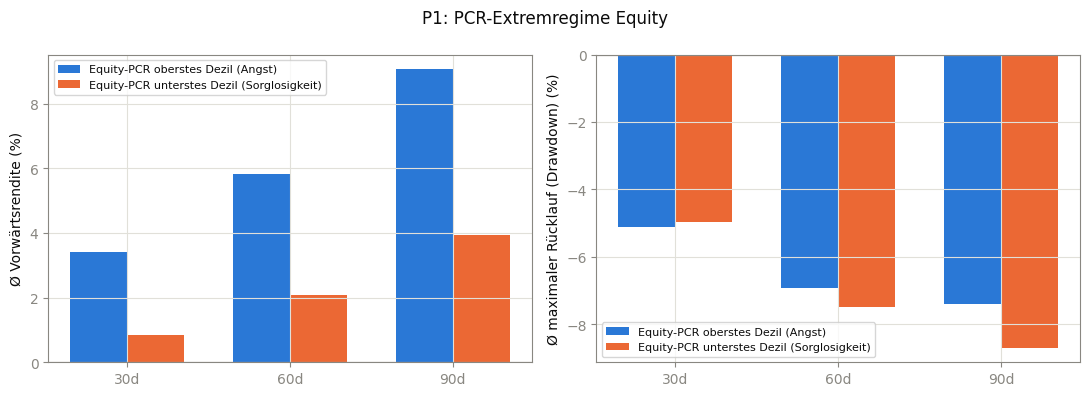

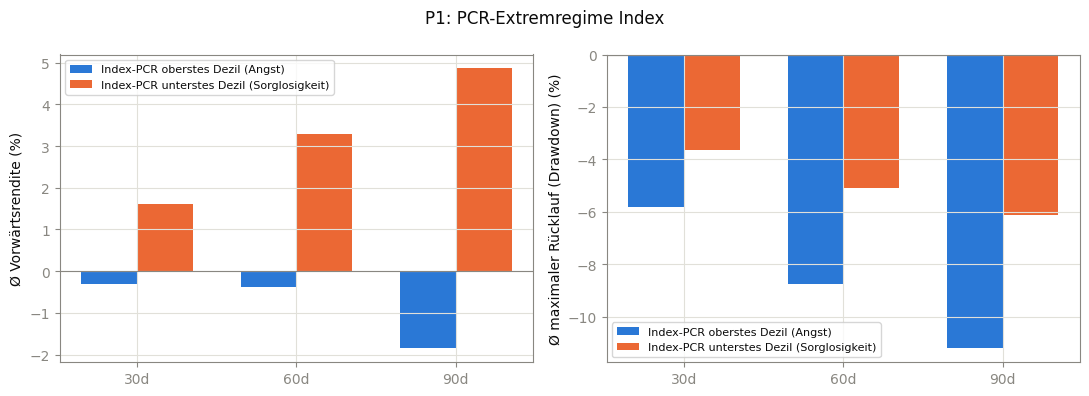

In [14]:
for reihe in PCR_SERIES:
    plotte_gruppenvergleich(tabelle_p1[tabelle_p1["reihe"] == reihe], f"P1: PCR-Extremregime {reihe}")

**Ergebnis:** Die drei Reihen zeigen ein deutlich unterschiedliches Bild.
Die **Equity-PCR** bestätigt die Kontraindikator-Hypothese sauber: Nach
Tagen im obersten Dezil (Angst) liegt die mittlere Vorwärtsrendite in allen
drei Horizonten signifikant höher als nach Tagen im untersten Dezil
(Sorglosigkeit) - von 3,4 % gegenüber 0,9 % (30 Tage) bis 9,1 % gegenüber
3,9 % (90 Tage); beim 90-Tage-Drawdown ist zudem das Risiko nach
Angst-Extremen geringer (-7,4 % gegenüber -8,7 %). Die **Index-PCR** zeigt
dagegen in allen sechs Kombinationen ein signifikant *entgegengesetztes*
Bild: Nach Angst-Extremen ist die Folgerendite niedriger (teils sogar
negativ, z. B. -1,9 % gegenüber +4,9 % bei 90 Tagen) und der Drawdown
deutlich größer (-11,2 % gegenüber -6,1 %). Das deckt sich mit der
eingangs beschriebenen institutionellen Hedging-Verzerrung: Eine hohe
Index-PCR signalisiert eher eine bereits laufende Risikophase als eine
kontrarische Kaufgelegenheit. Die **Total-PCR** liegt dazwischen (4 von 6
signifikant, Risiko durchgehend im erwarteten Sinne, Rendite nur beim
kürzesten Horizont) - plausibel, da sie beide Effekte mischt.

### 4.2 P2 - Richtung der PCR (steigend vs. fallend)

**Hypothese:** Unabhängig vom Niveau der PCR könnte bereits ihre Richtung
(nimmt die Put-Nachfrage gerade zu oder ab?) Information über die
Folgeperiode liefern. Als Kontraindikator gelesen: eine steigende PCR
(zunehmende Angst) sollte eher mit einer günstigeren Folgeperiode
einhergehen als eine fallende PCR (zunehmende Sorglosigkeit).

In [15]:
def pcr_richtung(reihe: str, fenster: int = PCR_FENSTER_REGIME) -> tuple[pd.Series, pd.Series]:
    ma_diff = df[f"{reihe}_ma{fenster}"].diff()
    steigend = ma_diff > 0
    fallend = ma_diff <= 0
    return steigend, fallend


ergebnisse_p2 = []
for reihe in PCR_SERIES:
    steigend, fallend = pcr_richtung(reihe)
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[steigend, f"{ziel}_{h}d"], df.loc[fallend, f"{ziel}_{h}d"],
                label_a=f"{reihe}-PCR steigend", label_b=f"{reihe}-PCR fallend",
            )
            if res:
                res.update({"reihe": reihe, "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_p2.append(res)

tabelle_p2 = ergebnisse_zu_tabelle(ergebnisse_p2)
alle_ergebnisse["P2_PCR_Richtung"] = tabelle_p2
tabelle_p2[spalten_anzeige]

,reihe,horizont_tage,zielgröße,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Total,30,fwd_return,Total-PCR steigend,0.0133,Total-PCR fallend,0.0102,0.0514,0.0471,False
1,Total,30,fwd_mdd,Total-PCR steigend,-0.0516,Total-PCR fallend,-0.0512,0.7346,0.1121,False
2,Total,60,fwd_return,Total-PCR steigend,0.0249,Total-PCR fallend,0.0224,0.2614,0.3397,False
3,Total,60,fwd_mdd,Total-PCR steigend,-0.0755,Total-PCR fallend,-0.0759,0.8429,0.2800,False
4,Total,90,fwd_return,Total-PCR steigend,0.0369,Total-PCR fallend,0.0338,0.2478,0.2399,False
5,Total,90,fwd_mdd,Total-PCR steigend,-0.0934,Total-PCR fallend,-0.0936,0.9339,0.9951,False
6,Equity,30,fwd_return,Equity-PCR steigend,0.0133,Equity-PCR fallend,0.0102,0.0528,0.0167,False
7,Equity,30,fwd_mdd,Equity-PCR steigend,-0.0518,Equity-PCR fallend,-0.0510,0.5194,0.1563,False
8,Equity,60,fwd_return,Equity-PCR steigend,0.0239,Equity-PCR fallend,0.0234,0.8303,0.9745,False
9,Equity,60,fwd_mdd,Equity-PCR steigend,-0.0760,Equity-PCR fallend,-0.0754,0.7441,0.2000,False


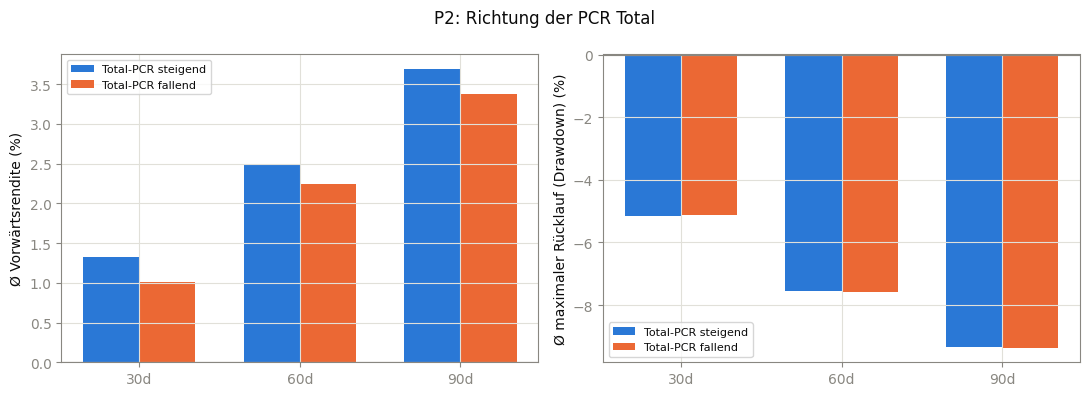

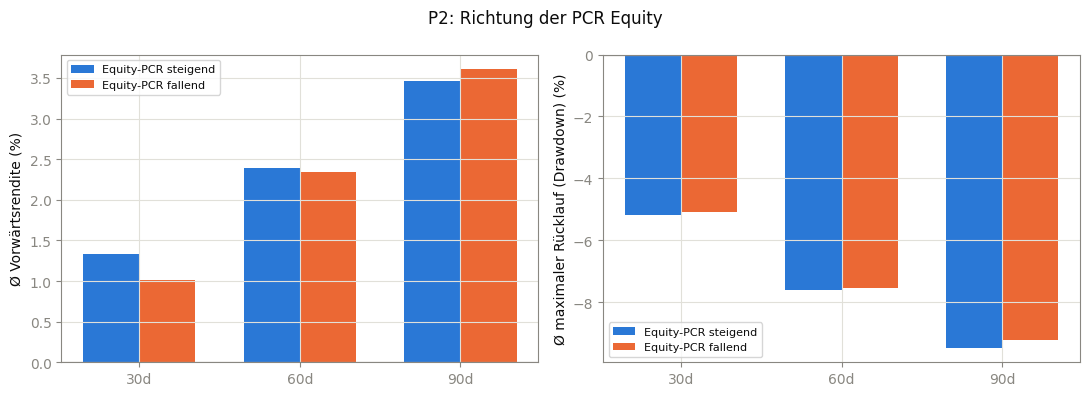

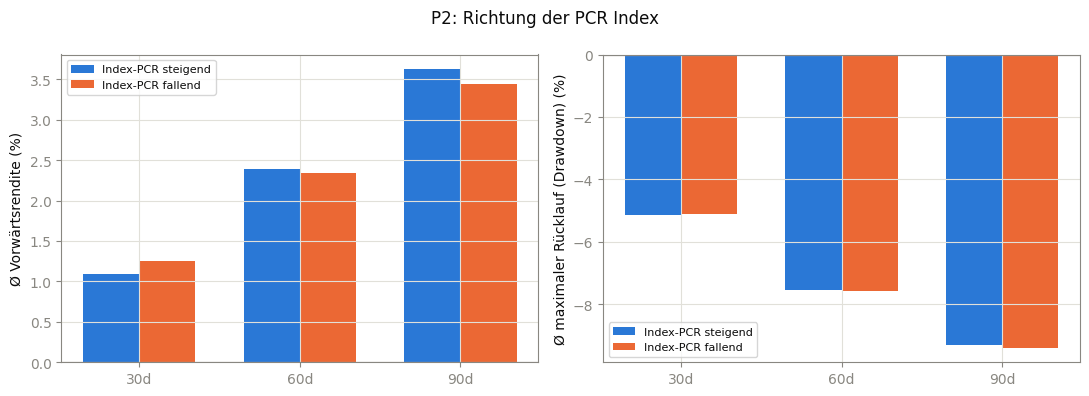

In [16]:
for reihe in PCR_SERIES:
    plotte_gruppenvergleich(tabelle_p2[tabelle_p2["reihe"] == reihe], f"P2: Richtung der PCR {reihe}")

**Ergebnis:** Die reine *Richtung* der PCR unabhängig von ihrem Niveau
liefert kein eigenständiges Signal:
Keine der 18 getesteten Kombinationen (3 Reihen x 3 Horizonte x 2
Zielgrößen) ist signifikant, und die Mittelwertunterschiede zwischen
steigender und fallender PCR sind durchgehend klein (z. B. Equity
90-Tage-Rendite 3,5 % steigend gegenüber 3,6 % fallend). Die tägliche
Richtungsänderung eines bereits geglätteten 10-Tage-Durchschnitts bildet
offenbar vor allem Rauschen ab.

### 4.3 P3 - PCR in Quartilen

**Hypothese:** Die Wirkung der PCR ist nicht binär, sondern graduell
abgestuft: Je höher die PCR (Q4 = höchste Angst), desto günstiger das
Rendite-/Risikoprofil der Folgeperiode; je niedriger (Q1 = höchste
Sorglosigkeit), desto ungünstiger. Getestet wird mit einem
Kruskal-Wallis-Omnibustest über alle vier (mengengleichen) Quartile sowie
einem paarweisen Extremvergleich Q1 vs. Q4.

In [17]:
def pcr_quartil(reihe: str, fenster: int = PCR_FENSTER_REGIME) -> pd.Series:
    ma = df[f"{reihe}_ma{fenster}"]
    return pd.qcut(ma, 4, labels=QUARTIL_LABELS)


ergebnisse_p3 = []
for reihe in PCR_SERIES:
    quartil = pcr_quartil(reihe)
    df[f"Quartil_{reihe}"] = quartil
    print(f"{reihe} - Verteilung der Handelstage auf die Quartile:")
    print(quartil.value_counts().reindex(QUARTIL_LABELS))
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            gruppen = {label: df.loc[quartil == label, f"{ziel}_{h}d"] for label in QUARTIL_LABELS}
            res = vergleiche_quartile(gruppen)
            if res:
                res.update({"reihe": reihe, "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_p3.append(res)

tabelle_p3 = ergebnisse_zu_tabelle(ergebnisse_p3)
alle_ergebnisse["P3_PCR_Quartile"] = tabelle_p3
cols_p3 = ["reihe", "horizont_tage", "zielgröße"] + [f"mean_{l}" for l in QUARTIL_LABELS] + \
          ["kw_pvalue", "kw_signifikant_5pct", "q1_vs_q4_signifikant_5pct"]
tabelle_p3[cols_p3]

Total - Verteilung der Handelstage auf die Quartile:
Total_ma10
Q1 (niedrigste PCR)    1222
Q2                     1221
Q3                     1221
Q4 (höchste PCR)       1221
Name: count, dtype: int64
Equity - Verteilung der Handelstage auf die Quartile:
Equity_ma10
Q1 (niedrigste PCR)    1222
Q2                     1221
Q3                     1221
Q4 (höchste PCR)       1221
Name: count, dtype: int64
Index - Verteilung der Handelstage auf die Quartile:
Index_ma10
Q1 (niedrigste PCR)    1223
Q2                     1220
Q3                     1221
Q4 (höchste PCR)       1221
Name: count, dtype: int64


,reihe,horizont_tage,zielgröße,mean_Q1 (niedrigste PCR),mean_Q2,mean_Q3,mean_Q4 (höchste PCR),kw_pvalue,kw_signifikant_5pct,q1_vs_q4_signifikant_5pct
0,Total,30,fwd_return,0.0107,0.0100,0.0088,0.0174,0.0000,True,True
1,Total,30,fwd_mdd,-0.0480,-0.0452,-0.0510,-0.0612,0.0000,True,True
2,Total,60,fwd_return,0.0272,0.0241,0.0128,0.0306,0.0000,True,False
3,Total,60,fwd_mdd,-0.0728,-0.0660,-0.0802,-0.0835,0.0000,True,True
4,Total,90,fwd_return,0.0458,0.0366,0.0225,0.0368,0.0000,True,False
5,Total,90,fwd_mdd,-0.0872,-0.0847,-0.0982,-0.1035,0.0000,True,True
6,Equity,30,fwd_return,0.0042,0.0017,0.0181,0.0228,0.0000,True,True
7,Equity,30,fwd_mdd,-0.0544,-0.0569,-0.0438,-0.0505,0.0000,True,True
8,Equity,60,fwd_return,0.0135,0.0076,0.0264,0.0465,0.0000,True,True
9,Equity,60,fwd_mdd,-0.0837,-0.0865,-0.0670,-0.0659,0.0000,True,True


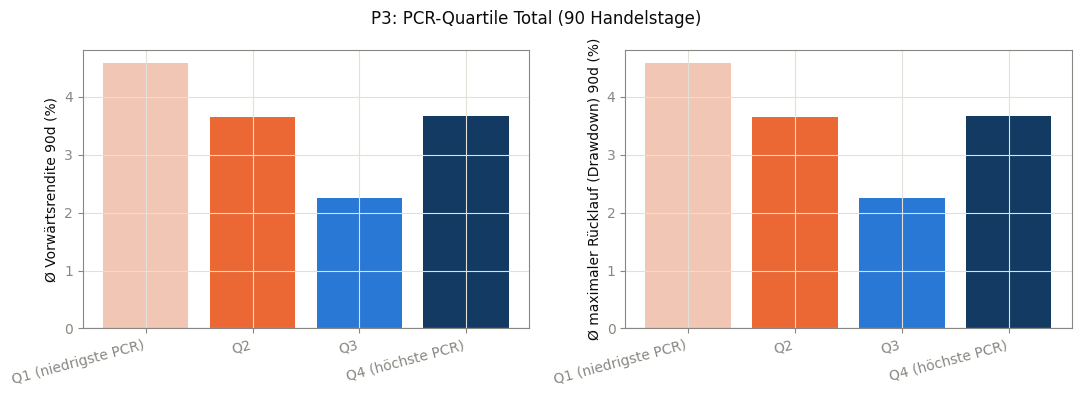

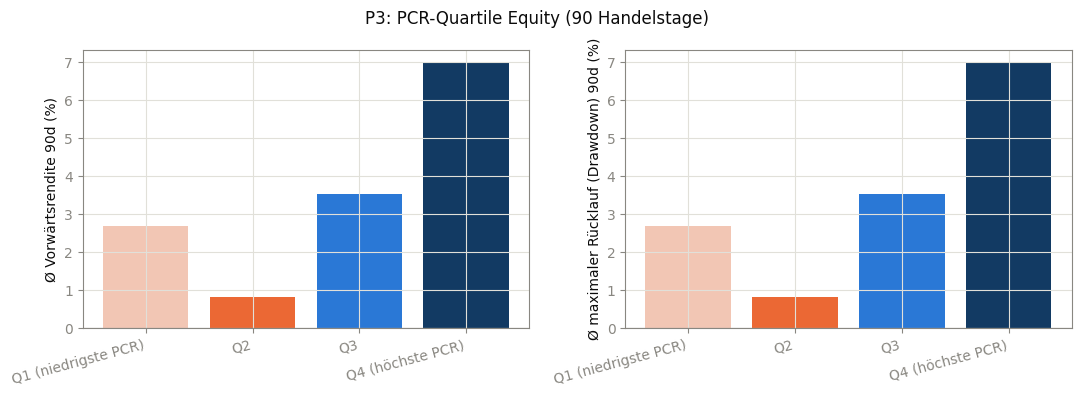

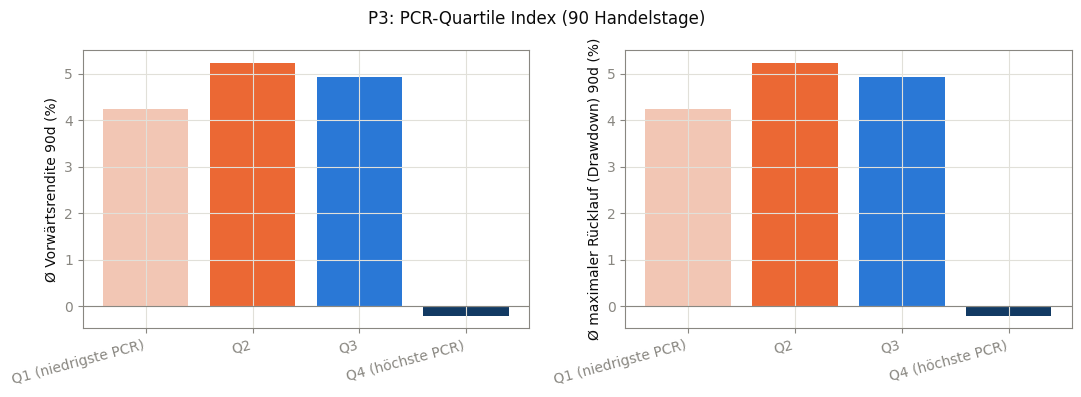

In [18]:
for reihe in PCR_SERIES:
    teil_return = tabelle_p3[(tabelle_p3["reihe"] == reihe) & (tabelle_p3["zielgröße"] == "fwd_return")]
    plotte_quartile(teil_return, 90, f"P3: PCR-Quartile {reihe} (90 Handelstage)")

**Ergebnis:** Alle 18 Kruskal-Wallis-Omnibustests sind signifikant, das
Bild unterscheidet sich zwischen den Reihen aber deutlich. Bei **Equity**
verläuft der Gradient sauber monoton: Von Q1 (niedrigste PCR) zu Q4
(höchste PCR) steigt die mittlere 90-Tage-Rendite von 2,7 % auf 7,0 %, der
mittlere 90-Tage-Drawdown verbessert sich von -10,1 % auf -7,5 % - ein
Lehrbuchbeispiel für den erwarteten Kontraindikator-Effekt. Bei **Index**
ist der Gradient ebenso monoton, aber invertiert: Rendite fällt von Q1
(4,2 %) auf Q4 (-0,2 %), der Drawdown verschlechtert sich von -7,0 % auf
-12,6 % - hohe Index-PCR geht mit schlechteren, nicht besseren
Folgeperioden einher. Bei **Total** zeigt sich dagegen kein sauberer
Gradient, sondern ein U-förmiges Muster: Sowohl das unterste als auch das
oberste Quartil liegen bei der 90-Tage-Rendite über den mittleren
Quartilen (4,6 % bzw. 3,7 % gegenüber 2,3-3,7 %) - ein Extremquartil-Effekt: Beide Randquartile schneiden bei der
Rendite besser ab als die mittleren Quartile.

### 4.4 Gemeinsames Vorgehen für P4 und P5

Beide Hypothesen basieren auf einem Ausbruch der schnellen PCR (5-Tage-
Durchschnitt) aus einer ruhigen Ausgangslage der langsamen PCR (21-Tage-
Durchschnitt) und werden mit derselben Funktion ausgewertet.

In [19]:
def frühindikator_ausbruch(fast: pd.Series, slow: pd.Series, fast_schwelle: float,
                             slow_ruhig_schwelle: float, richtung: str) -> pd.Series:
    '''Signalisiert den Tag, an dem `fast` erstmals die Schwelle
    `fast_schwelle` in Richtung `richtung` ("über" oder "unter")
    durchbricht, nachdem `slow` zuvor innerhalb der ruhigen Zone lag (noch
    nicht selbst über/unter `slow_ruhig_schwelle`) - auf Basis der 5- vs.
    21-Tage-PCR (schnelles vs. langsames Glättungsfenster).'''
    signal = pd.Series(False, index=fast.index)
    ist_ruhig = (lambda s: s < slow_ruhig_schwelle) if richtung == "über" else (lambda s: s > slow_ruhig_schwelle)
    auslöser = (lambda f: f > fast_schwelle) if richtung == "über" else (lambda f: f < fast_schwelle)
    war_ruhig = False
    for datum in fast.index:
        f, s = fast[datum], slow[datum]
        if pd.isna(f) or pd.isna(s):
            continue
        if not ist_ruhig(s):
            war_ruhig = False
            continue
        war_ruhig = True
        if war_ruhig and auslöser(f):
            signal[datum] = True
            war_ruhig = False
    return signal


print("Gemeinsame Frühindikator-Funktion definiert.")

Gemeinsame Frühindikator-Funktion definiert.


### 4.5 P4 - Frühindikator Angst-Spitze

**Hypothese:** Ausgangslage ist eine ruhige Marktlage (21-Tage-PCR unterhalb
ihres eigenen 75. Perzentils). Schiesst die schnelle 5-Tage-PCR anschließend
über ihr eigenes 90. Perzentil, während die langsame PCR selbst noch nicht
dort angekommen ist, deutet dies auf einen beginnenden, von der breiteren
Optionsmarktstimmung noch nicht bestätigten Angst-Ausbruch hin - als
Kontraindikator möglicherweise ein frühes Kaufsignal.

In [20]:
ergebnisse_p4 = []
for reihe in PCR_SERIES:
    fast = df[f"{reihe}_ma{PCR_FENSTER_FAST}"]
    slow = df[f"{reihe}_ma{PCR_FENSTER_SLOW}"]
    fast_schwelle = fast.quantile(0.90)
    slow_ruhig_schwelle = slow.quantile(0.75)
    signal = frühindikator_ausbruch(fast, slow, fast_schwelle, slow_ruhig_schwelle, richtung="über")
    n = int(signal.sum())
    print(f"{reihe}: {n} P4-Ereignisse identifiziert")
    ergebnisse, einzel = ereignis_hypothese(signal, f"P4-Signal {reihe}", {"reihe": reihe})
    ergebnisse_p4.extend(ergebnisse)
    if einzel is not None:
        alle_ergebnisse[f"P4_Angst_Spitze_{reihe}_einzel"] = einzel

tabelle_p4 = ergebnisse_zu_tabelle(ergebnisse_p4)
alle_ergebnisse["P4_Angst_Spitze"] = tabelle_p4
tabelle_p4

Total: 97 P4-Ereignisse identifiziert


Equity: 99 P4-Ereignisse identifiziert


Index: 6 P4-Ereignisse identifiziert


,label_a,n_a,mean_a,median_a,std_a,label_b,n_b,mean_b,median_b,std_b,t_pvalue,u_pvalue,signifikant_5pct,reihe,horizont_tage,zielgröße,n_events
0,P4-Signal Total,97,0.0094,0.0163,0.0492,Basisrate (alle Tage),4865,0.0117,0.0181,0.0561,0.6533,0.3863,False,Total,30,fwd_return,97
1,P4-Signal Total,97,-0.0650,-0.0458,0.0661,Basisrate (alle Tage),4865,-0.0514,-0.0390,0.0462,0.0463,0.0121,True,Total,30,fwd_mdd,97
2,P4-Signal Total,97,0.0241,0.0256,0.0595,Basisrate (alle Tage),4836,0.0237,0.0347,0.0765,0.9454,0.2403,False,Total,60,fwd_return,97
3,P4-Signal Total,97,-0.0886,-0.0587,0.0684,Basisrate (alle Tage),4836,-0.0757,-0.0569,0.0623,0.0670,0.0260,False,Total,60,fwd_mdd,97
4,P4-Signal Total,97,0.0471,0.0427,0.0613,Basisrate (alle Tage),4806,0.0354,0.0478,0.0934,0.0696,0.9855,False,Total,90,fwd_return,97
5,P4-Signal Total,97,-0.0951,-0.0612,0.0670,Basisrate (alle Tage),4806,-0.0934,-0.0720,0.0727,0.8131,0.6408,False,Total,90,fwd_mdd,97
6,P4-Signal Equity,99,0.0161,0.0159,0.0537,Basisrate (alle Tage),4865,0.0117,0.0181,0.0561,0.4211,0.6635,False,Equity,30,fwd_return,99
7,P4-Signal Equity,99,-0.0609,-0.0458,0.0672,Basisrate (alle Tage),4865,-0.0514,-0.0390,0.0462,0.1660,0.5422,False,Equity,30,fwd_mdd,99
8,P4-Signal Equity,99,0.0361,0.0379,0.0558,Basisrate (alle Tage),4836,0.0237,0.0347,0.0765,0.0311,0.3364,False,Equity,60,fwd_return,99
9,P4-Signal Equity,99,-0.0798,-0.0573,0.0699,Basisrate (alle Tage),4836,-0.0757,-0.0569,0.0623,0.5574,0.7940,False,Equity,60,fwd_mdd,99


**Ergebnis:** Mit 97 (Total) bzw. 99 (Equity) Ereignissen sind zwei der
drei Reihen testbar, bei Index reichen 6 Ereignisse nur für eine
deskriptive Auflistung. Die Evidenz ist schwach: Bei Total ist lediglich der
30-Tage-Drawdown signifikant - und zwar in die *unerwartete* Richtung (nach
dem Signal -6,5 % gegenüber -5,1 % Basisrate, also mehr statt weniger
Risiko). Bei Equity ist nur die 90-Tage-Rendite signifikant und stützt die
Hypothese (5,9 % gegenüber 3,5 %). Insgesamt liefert der schnelle
Angst-Ausbruch aus einer ruhigen Marktlage kein robustes Frühwarnsignal.

### 4.6 P5 - Frühindikator Sorglosigkeits-Spitze

**Hypothese:** Spiegelbild zu P4. Ausgangslage ist eine ruhige Marktlage
(21-Tage-PCR oberhalb ihres eigenen 25. Perzentils, d. h. noch nicht in
einer Sorglosigkeits-Phase). Fällt die schnelle 5-Tage-PCR anschließend
unter ihr eigenes 10. Perzentil, während die langsame PCR selbst noch nicht
dort angekommen ist, deutet dies auf einen beginnenden, noch nicht
bestätigten Sorglosigkeits-Ausbruch hin - als Kontraindikator
möglicherweise ein frühes Warnsignal.

In [21]:
ergebnisse_p5 = []
for reihe in PCR_SERIES:
    fast = df[f"{reihe}_ma{PCR_FENSTER_FAST}"]
    slow = df[f"{reihe}_ma{PCR_FENSTER_SLOW}"]
    fast_schwelle = fast.quantile(0.10)
    slow_ruhig_schwelle = slow.quantile(0.25)
    signal = frühindikator_ausbruch(fast, slow, fast_schwelle, slow_ruhig_schwelle, richtung="unter")
    n = int(signal.sum())
    print(f"{reihe}: {n} P5-Ereignisse identifiziert")
    ergebnisse, einzel = ereignis_hypothese(signal, f"P5-Signal {reihe}", {"reihe": reihe})
    ergebnisse_p5.extend(ergebnisse)
    if einzel is not None:
        alle_ergebnisse[f"P5_Sorglosigkeit_Spitze_{reihe}_einzel"] = einzel

tabelle_p5 = ergebnisse_zu_tabelle(ergebnisse_p5)
alle_ergebnisse["P5_Sorglosigkeit_Spitze"] = tabelle_p5
tabelle_p5

Total: 75 P5-Ereignisse identifiziert


Equity: 21 P5-Ereignisse identifiziert


Index: 37 P5-Ereignisse identifiziert


,label_a,n_a,mean_a,median_a,std_a,label_b,n_b,mean_b,median_b,std_b,t_pvalue,u_pvalue,signifikant_5pct,reihe,horizont_tage,zielgröße,n_events
0,P5-Signal Total,74,0.0220,0.0289,0.0571,Basisrate (alle Tage),4865,0.0117,0.0181,0.0561,0.1277,0.0586,False,Total,30,fwd_return,75
1,P5-Signal Total,74,-0.0486,-0.0283,0.0548,Basisrate (alle Tage),4865,-0.0514,-0.0390,0.0462,0.6606,0.0111,False,Total,30,fwd_mdd,75
2,P5-Signal Total,74,0.0372,0.0423,0.0896,Basisrate (alle Tage),4836,0.0237,0.0347,0.0765,0.1999,0.2258,False,Total,60,fwd_return,75
3,P5-Signal Total,74,-0.0787,-0.0497,0.0684,Basisrate (alle Tage),4836,-0.0757,-0.0569,0.0623,0.7097,0.6469,False,Total,60,fwd_mdd,75
4,P5-Signal Total,68,0.0411,0.0380,0.1024,Basisrate (alle Tage),4806,0.0354,0.0478,0.0934,0.6454,0.8502,False,Total,90,fwd_return,75
5,P5-Signal Total,68,-0.0999,-0.0873,0.0720,Basisrate (alle Tage),4806,-0.0934,-0.0720,0.0727,0.4618,0.4239,False,Total,90,fwd_mdd,75
6,P5-Signal Equity,21,0.0161,0.0192,0.0432,Basisrate (alle Tage),4865,0.0117,0.0181,0.0561,0.6448,0.6018,False,Equity,30,fwd_return,21
7,P5-Signal Equity,21,-0.0400,-0.0365,0.0280,Basisrate (alle Tage),4865,-0.0514,-0.0390,0.0462,0.0784,0.3954,False,Equity,30,fwd_mdd,21
8,P5-Signal Equity,21,-0.0127,0.0128,0.0876,Basisrate (alle Tage),4836,0.0237,0.0347,0.0765,0.0717,0.0447,False,Equity,60,fwd_return,21
9,P5-Signal Equity,21,-0.1024,-0.1016,0.0687,Basisrate (alle Tage),4836,-0.0757,-0.0569,0.0623,0.0904,0.0109,False,Equity,60,fwd_mdd,21


**Ergebnis:** Bei Total (74-75 Ereignisse) ist keine der sechs
Kombinationen signifikant. Bei Equity (19-21 Ereignisse) und Index (37
Ereignisse) zeigt sich dagegen ein konsistentes, die Hypothese stützendes
Bild bei der Rendite: Equity 90-Tage-Rendite nach dem Signal -1,2 %
gegenüber 3,5 % Basisrate (signifikant), Index 60- und 90-Tage-Rendite
ebenfalls signifikant niedriger (z. B. 90 Tage: 1,3 % gegenüber 3,5 %). Ein
frischer Ausbruch der PCR in eine Sorglosigkeits-Spitze scheint bei Equity
und Index also tatsächlich mit einer schwächeren Folgeperiode
einherzugehen - anders als der breitere Regimevergleich in P1, wo niedrige
Index-PCR mit *besserer* Folgeperiode einherging. Dieser scheinbare
Widerspruch zwischen Regime-Niveau (P1) und frischem Ausbruch (P5) zeigt,
dass Timing des Übergangs und Dauerzustand unterschiedliche Information
tragen können, und wird in Abschnitt 5 eingeordnet.

### 4.7 P6 - Divergenz Equity- vs. Index-PCR

**Hypothese:** Die Equity-PCR spiegelt überwiegend Retail-Sentiment, die
Index-PCR überwiegend institutionelles Hedging wider. Laufen beide
auseinander, könnte das eine eigenständige Information gegenüber dem
Niveau jeder einzelnen Reihe liefern: (a) Equity niedrig (Retail sorglos)
bei gleichzeitig hoher Index-PCR (institutionell abgesichert) - "Smart
Money" positioniert sich defensiv, während Privatanleger sorglos bleiben;
(b) Equity hoch (Retail ängstlich) bei gleichzeitig niedriger Index-PCR
(institutionell entspannt) - Privatanleger-Panik ohne institutionelle
Bestätigung, möglicherweise ein Erschöpfungssignal.

In [22]:
equity_ma = df[f"Equity_ma{PCR_FENSTER_REGIME}"]
index_ma = df[f"Index_ma{PCR_FENSTER_REGIME}"]
equity_p33, equity_p67 = equity_ma.quantile([0.33, 0.67])
index_p33, index_p67 = index_ma.quantile([0.33, 0.67])

divergenz_a = (equity_ma <= equity_p33) & (index_ma >= index_p67)   # Retail sorglos, Institution defensiv
divergenz_b = (equity_ma >= equity_p67) & (index_ma <= index_p33)   # Retail ängstlich, Institution entspannt

print(f"Divergenz A (Retail sorglos / Institution defensiv): {int(divergenz_a.sum())} Tage")
print(f"Divergenz B (Retail ängstlich / Institution entspannt): {int(divergenz_b.sum())} Tage")

ergebnisse_p6 = []
tabelle_p6_einzel = {}
for label, signal in [("Divergenz_A_Retail_sorglos", divergenz_a), ("Divergenz_B_Retail_ängstlich", divergenz_b)]:
    ergebnisse, einzel = ereignis_hypothese(signal, label, {"variante": label})
    ergebnisse_p6.extend(ergebnisse)
    if einzel is not None:
        tabelle_p6_einzel[label] = einzel
        alle_ergebnisse[f"P6_{label}_einzel"] = einzel

tabelle_p6 = ergebnisse_zu_tabelle(ergebnisse_p6)
alle_ergebnisse["P6_Divergenz_Equity_Index"] = tabelle_p6
tabelle_p6

Divergenz A (Retail sorglos / Institution defensiv): 960 Tage
Divergenz B (Retail ängstlich / Institution entspannt): 575 Tage


,label_a,n_a,mean_a,median_a,std_a,label_b,n_b,mean_b,median_b,std_b,t_pvalue,u_pvalue,signifikant_5pct,variante,horizont_tage,zielgröße,n_events
0,Divergenz_A_Retail_sorglos,960,0.0025,0.0138,0.0597,Basisrate (alle Tage),4865,0.0117,0.0181,0.0561,0.0000,0.0006,True,Divergenz_A_Retail_sorglos,30,fwd_return,960
1,Divergenz_A_Retail_sorglos,960,-0.0574,-0.0433,0.0430,Basisrate (alle Tage),4865,-0.0514,-0.0390,0.0462,0.0001,0.0000,True,Divergenz_A_Retail_sorglos,30,fwd_mdd,960
2,Divergenz_A_Retail_sorglos,960,0.0064,0.0333,0.0916,Basisrate (alle Tage),4836,0.0237,0.0347,0.0765,0.0000,0.0009,True,Divergenz_A_Retail_sorglos,60,fwd_return,960
3,Divergenz_A_Retail_sorglos,960,-0.0904,-0.0748,0.0696,Basisrate (alle Tage),4836,-0.0757,-0.0569,0.0623,0.0000,0.0000,True,Divergenz_A_Retail_sorglos,60,fwd_mdd,960
4,Divergenz_A_Retail_sorglos,960,0.0098,0.0179,0.1064,Basisrate (alle Tage),4806,0.0354,0.0478,0.0934,0.0000,0.0000,True,Divergenz_A_Retail_sorglos,90,fwd_return,960
5,Divergenz_A_Retail_sorglos,960,-0.1113,-0.0943,0.0801,Basisrate (alle Tage),4806,-0.0934,-0.0720,0.0727,0.0000,0.0000,True,Divergenz_A_Retail_sorglos,90,fwd_mdd,960
6,Divergenz_B_Retail_ängstlich,575,0.0198,0.0281,0.0448,Basisrate (alle Tage),4865,0.0117,0.0181,0.0561,0.0001,0.0013,True,Divergenz_B_Retail_ängstlich,30,fwd_return,575
7,Divergenz_B_Retail_ängstlich,575,-0.0375,-0.0307,0.0313,Basisrate (alle Tage),4865,-0.0514,-0.0390,0.0462,0.0000,0.0000,True,Divergenz_B_Retail_ängstlich,30,fwd_mdd,575
8,Divergenz_B_Retail_ängstlich,575,0.0332,0.0415,0.0598,Basisrate (alle Tage),4836,0.0237,0.0347,0.0765,0.0005,0.0071,True,Divergenz_B_Retail_ängstlich,60,fwd_return,575
9,Divergenz_B_Retail_ängstlich,575,-0.0547,-0.0398,0.0419,Basisrate (alle Tage),4836,-0.0757,-0.0569,0.0623,0.0000,0.0000,True,Divergenz_B_Retail_ängstlich,60,fwd_mdd,575


**Ergebnis:** Beide Divergenz-Varianten sind in allen 12 Kombinationen
signifikant - das robusteste Ergebnis der gesamten Analyse. Divergenz A
(Retail sorglos, Institution defensiv, 960 Tage) geht durchgehend mit
niedrigerer Rendite (z. B. 90 Tage: 1,0 % gegenüber 3,5 % Basisrate) und
höherem Risiko einher (90-Tage-Drawdown -11,1 % gegenüber -9,3 %).
Divergenz B (Retail ängstlich, Institution entspannt, 575 Tage) zeigt genau
das Gegenteil: höhere Rendite (90 Tage: 5,0 % gegenüber 3,5 %) und
geringeres Risiko (-6,7 % gegenüber -9,3 %). Das Auseinanderlaufen von
Retail- und institutionellem Sentiment liefert damit ein deutlich klareres
Signal als das Niveau jeder einzelnen Reihe für sich.

### 4.8 P7 - Wochentrend + PCR-Extrem kombiniert

**Hypothese:** (a) Der wöchentliche Indextrend ist positiv, aber die
10-Tage-PCR schiesst dennoch über ihr eigenes 90. Perzentil - eine
Angst-Übertreibung trotz intaktem Aufwärtstrend, möglicherweise eine
Kaufgelegenheit. (b) Der wöchentliche Trend ist negativ, aber die PCR
fällt unter ihr eigenes 10. Perzentil - Sorglosigkeit trotz
Abwärtstrend, möglicherweise ein Warnsignal für eine noch nicht
abgeschlossene Abwärtsbewegung (keine Kapitulation sichtbar).

In [23]:
def kreuzt_über(reihe: pd.Series, schwelle: float) -> pd.Series:
    return (reihe > schwelle) & (reihe.shift(1) <= schwelle)


def kreuzt_unter(reihe: pd.Series, schwelle: float) -> pd.Series:
    return (reihe < schwelle) & (reihe.shift(1) >= schwelle)


ergebnisse_p7 = []
for reihe in PCR_SERIES:
    ma = df[f"{reihe}_ma{PCR_FENSTER_REGIME}"]
    p10, p90 = ma.quantile([0.10, 0.90])

    signal_a = (df["Wochentrend_positiv"] == 1) & kreuzt_über(ma, p90)
    signal_b = (df["Wochentrend_positiv"] == 0) & kreuzt_unter(ma, p10)

    for label, signal in [(f"{reihe}_Trend_positiv_PCR_Angst", signal_a),
                           (f"{reihe}_Trend_negativ_PCR_Sorglos", signal_b)]:
        n = int(signal.sum())
        print(f"{label}: {n} Ereignisse")
        ergebnisse, einzel = ereignis_hypothese(signal, label, {"reihe": reihe, "variante": label})
        ergebnisse_p7.extend(ergebnisse)
        if einzel is not None:
            alle_ergebnisse[f"P7_{label}_einzel"] = einzel

tabelle_p7 = ergebnisse_zu_tabelle(ergebnisse_p7)
alle_ergebnisse["P7_Wochentrend_PCR_Extrem"] = tabelle_p7
tabelle_p7

Total_Trend_positiv_PCR_Angst: 30 Ereignisse
Total_Trend_negativ_PCR_Sorglos: 7 Ereignisse
Equity_Trend_positiv_PCR_Angst: 36 Ereignisse


Equity_Trend_negativ_PCR_Sorglos: 3 Ereignisse
Index_Trend_positiv_PCR_Angst: 17 Ereignisse
Index_Trend_negativ_PCR_Sorglos: 3 Ereignisse


,label_a,n_a,mean_a,median_a,std_a,label_b,n_b,mean_b,median_b,std_b,t_pvalue,u_pvalue,signifikant_5pct,reihe,variante,horizont_tage,zielgröße,n_events
0,Total_Trend_positiv_PCR_Angst,30,0.0123,0.0194,0.0497,Basisrate (alle Tage),4865,0.0117,0.0181,0.0561,0.9440,0.9408,False,Total,Total_Trend_positiv_PCR_Angst,30,fwd_return,30
1,Total_Trend_positiv_PCR_Angst,30,-0.0529,-0.0405,0.0504,Basisrate (alle Tage),4865,-0.0514,-0.0390,0.0462,0.8718,0.5999,False,Total,Total_Trend_positiv_PCR_Angst,30,fwd_mdd,30
2,Total_Trend_positiv_PCR_Angst,30,0.0409,0.0514,0.0505,Basisrate (alle Tage),4836,0.0237,0.0347,0.0765,0.0734,0.1830,False,Total,Total_Trend_positiv_PCR_Angst,60,fwd_return,30
3,Total_Trend_positiv_PCR_Angst,30,-0.0713,-0.0560,0.0563,Basisrate (alle Tage),4836,-0.0757,-0.0569,0.0623,0.6725,0.8041,False,Total,Total_Trend_positiv_PCR_Angst,60,fwd_mdd,30
4,Total_Trend_positiv_PCR_Angst,30,0.0723,0.0764,0.0587,Basisrate (alle Tage),4806,0.0354,0.0478,0.0934,0.0018,0.0175,True,Total,Total_Trend_positiv_PCR_Angst,90,fwd_return,30
5,Total_Trend_positiv_PCR_Angst,30,-0.0725,-0.0560,0.0567,Basisrate (alle Tage),4806,-0.0934,-0.0720,0.0727,0.0532,0.0395,False,Total,Total_Trend_positiv_PCR_Angst,90,fwd_mdd,30
6,Equity_Trend_positiv_PCR_Angst,36,0.0143,0.0279,0.0428,Basisrate (alle Tage),4865,0.0117,0.0181,0.0561,0.7191,0.7692,False,Equity,Equity_Trend_positiv_PCR_Angst,30,fwd_return,36
7,Equity_Trend_positiv_PCR_Angst,36,-0.0440,-0.0316,0.0466,Basisrate (alle Tage),4865,-0.0514,-0.0390,0.0462,0.3482,0.2165,False,Equity,Equity_Trend_positiv_PCR_Angst,30,fwd_mdd,36
8,Equity_Trend_positiv_PCR_Angst,36,0.0314,0.0363,0.0429,Basisrate (alle Tage),4836,0.0237,0.0347,0.0765,0.2912,0.8220,False,Equity,Equity_Trend_positiv_PCR_Angst,60,fwd_return,36
9,Equity_Trend_positiv_PCR_Angst,36,-0.0635,-0.0558,0.0524,Basisrate (alle Tage),4836,-0.0757,-0.0569,0.0623,0.1760,0.1894,False,Equity,Equity_Trend_positiv_PCR_Angst,60,fwd_mdd,36


**Ergebnis:** Bei kleinen Stichproben (17-36 Ereignisse je Kombination)
ist die Evidenz erwartungsgemäß gemischt: Nur 3 von 18 getesteten Fällen
sind signifikant (u. a. Index/30-Tage-Rendite: 4,0 % gegenüber 1,2 %
Basisrate; Equity/90-Tage-Drawdown: -6,9 % gegenüber -9,3 %), jeweils im
Sinne der Hypothese. Die Kombination aus Wochentrend und PCR-Extrem liefert
damit vereinzelte, aber angesichts der geringen Fallzahlen nicht robust
verallgemeinerbare Hinweise.

### 4.9 P8 - Intraday-Spike vs. Close-Bestätigung

**Hypothese:** An Tagen mit einem auffälligen Tageshoch der PCR (oberstes
Quartil des Tageshochs) ist entscheidend, ob der Schlusskurs nahe am Hoch
verbleibt ("bestätigtes" Angst-Extrem) oder weit zurück in Richtung
Tagestief fällt ("verpuffter" Ausschlag). Genutzt wird dafür erstmals die
Intraday-Spanne (High/Low) statt nur des Schlusswerts. Erwartet wird ein
Unterschied in der Folgeperiode zwischen beiden Gruppen.

In [24]:
ergebnisse_p8 = []
for reihe in PCR_SERIES:
    high = df[f"{reihe}_high"]
    low = df[f"{reihe}_low"]
    close = df[f"{reihe}_close"]
    spanne = high - low
    position_im_tag = np.where(spanne > 0, (close - low) / spanne, np.nan)
    position_im_tag = pd.Series(position_im_tag, index=df.index)

    hoch_auffällig = high >= high.quantile(0.75)
    bestätigt = hoch_auffällig & (position_im_tag >= 0.66)
    verpufft = hoch_auffällig & (position_im_tag <= 0.33)

    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[bestätigt, f"{ziel}_{h}d"], df.loc[verpufft, f"{ziel}_{h}d"],
                label_a=f"{reihe} Close-bestätigtes Hoch", label_b=f"{reihe} verpuffter Intraday-Spike",
            )
            if res:
                res.update({"reihe": reihe, "horizont_tage": h, "zielgröße": ziel,
                             "n_bestätigt": int(bestätigt.sum()), "n_verpufft": int(verpufft.sum())})
                ergebnisse_p8.append(res)

tabelle_p8 = ergebnisse_zu_tabelle(ergebnisse_p8)
alle_ergebnisse["P8_Intraday_Spike_vs_Bestätigung"] = tabelle_p8
tabelle_p8[spalten_anzeige]

,reihe,horizont_tage,zielgröße,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Total,30,fwd_return,Total Close-bestätigtes Hoch,0.0189,Total verpuffter Intraday-Spike,0.0129,0.2044,0.0705,False
1,Total,30,fwd_mdd,Total Close-bestätigtes Hoch,-0.0561,Total verpuffter Intraday-Spike,-0.0493,0.0924,0.0049,False
2,Total,60,fwd_return,Total Close-bestätigtes Hoch,0.0301,Total verpuffter Intraday-Spike,0.0260,0.4917,0.3359,False
3,Total,60,fwd_mdd,Total Close-bestätigtes Hoch,-0.0817,Total verpuffter Intraday-Spike,-0.0695,0.0119,0.0004,True
4,Total,90,fwd_return,Total Close-bestätigtes Hoch,0.0349,Total verpuffter Intraday-Spike,0.0387,0.6402,0.7673,False
5,Total,90,fwd_mdd,Total Close-bestätigtes Hoch,-0.1039,Total verpuffter Intraday-Spike,-0.0857,0.0029,0.0003,True
6,Equity,30,fwd_return,Equity Close-bestätigtes Hoch,0.0257,Equity verpuffter Intraday-Spike,0.0179,0.0618,0.0079,False
7,Equity,30,fwd_mdd,Equity Close-bestätigtes Hoch,-0.0505,Equity verpuffter Intraday-Spike,-0.0460,0.1816,0.0004,False
8,Equity,60,fwd_return,Equity Close-bestätigtes Hoch,0.0409,Equity verpuffter Intraday-Spike,0.0366,0.3974,0.3136,False
9,Equity,60,fwd_mdd,Equity Close-bestätigtes Hoch,-0.0709,Equity verpuffter Intraday-Spike,-0.0634,0.0694,0.0031,False


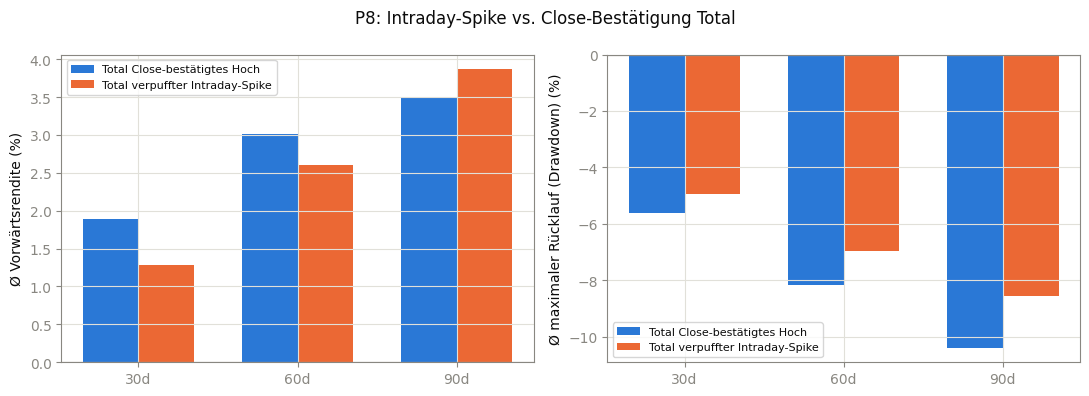

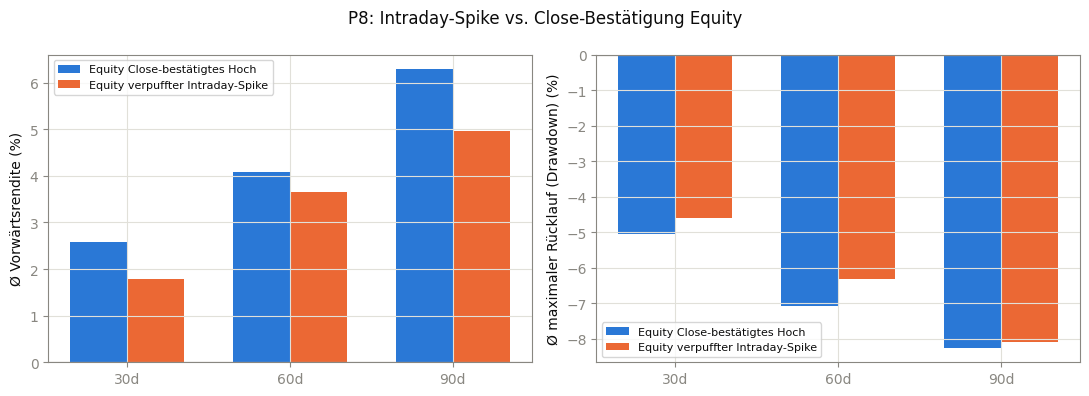

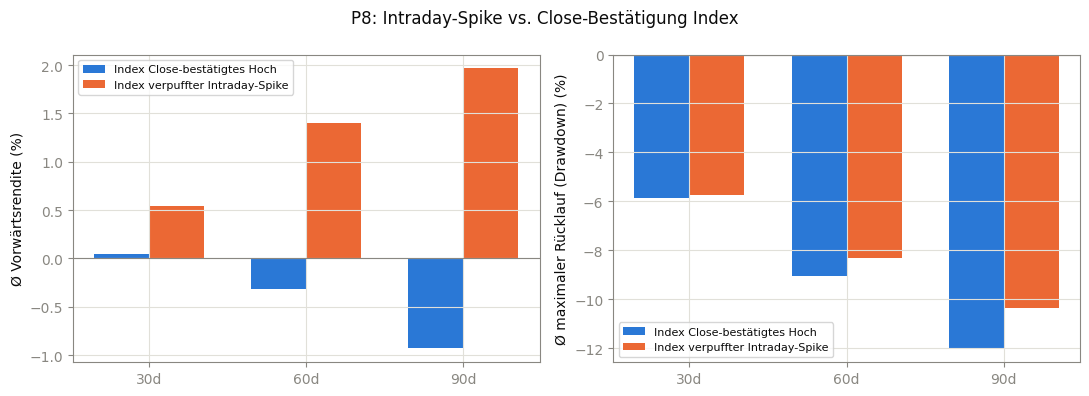

In [25]:
for reihe in PCR_SERIES:
    plotte_gruppenvergleich(tabelle_p8[tabelle_p8["reihe"] == reihe], f"P8: Intraday-Spike vs. Close-Bestätigung {reihe}")

**Ergebnis:** Die Nutzung von High/Low statt nur des Schlusswerts
liefert ein eigenständiges Signal: Bleibt der Schlusswert nahe am
Tageshoch (bestätigtes Extrem), ist das nachfolgende Risiko bei Total
signifikant höher als wenn der Ausschlag bis zum Handelsschluss wieder
verpufft (90-Tage-Drawdown -10,4 % gegenüber -8,6 %). Das ist plausibel:
Ein bis zum Schluss anhaltender Angst-Ausschlag deutet auf eine ernstere,
nicht nur untertägige Verunsicherung hin. Insgesamt ist der Effekt mit 4
von 18 signifikanten Kombinationen jedoch schwächer als bei P1/P3/P6 - die
Bestätigung durch den Schlusskurs verstärkt das Signal, ersetzt aber
nicht die Notwendigkeit, zusätzlich das PCR-Niveau selbst zu betrachten.

### 4.10 P9 - PCR Thrust/Collapse

**Hypothese:** Ein besonders schneller Anstieg ("Thrust", rasch zunehmende
Angst) oder Rückgang ("Collapse", rasch zunehmende Sorglosigkeit) der
5-Tage-PCR binnen 10 Handelstagen trägt eigenständige Information über
die Folgeperiode - unabhängig vom bereits in P1-P3 geprüften Niveau.

In [26]:
THRUST_FENSTER = 10

ergebnisse_p9 = []
for reihe in PCR_SERIES:
    fast = df[f"{reihe}_ma{PCR_FENSTER_FAST}"]
    delta = fast - fast.shift(THRUST_FENSTER)
    p10, p90 = delta.quantile([0.10, 0.90])
    thrust = delta >= p90
    collapse = delta <= p10

    for label, signal in [(f"{reihe}_Thrust", thrust), (f"{reihe}_Collapse", collapse)]:
        n = int(signal.sum())
        print(f"{label}: {n} Ereignisse")
        ergebnisse, einzel = ereignis_hypothese(signal, label, {"reihe": reihe, "variante": label})
        ergebnisse_p9.extend(ergebnisse)
        if einzel is not None:
            alle_ergebnisse[f"P9_{label}_einzel"] = einzel

tabelle_p9 = ergebnisse_zu_tabelle(ergebnisse_p9)
alle_ergebnisse["P9_Thrust_Collapse"] = tabelle_p9
tabelle_p9

Total_Thrust: 488 Ereignisse
Total_Collapse: 489 Ereignisse
Equity_Thrust: 488 Ereignisse
Equity_Collapse: 489 Ereignisse
Index_Thrust: 488 Ereignisse


Index_Collapse: 488 Ereignisse


,label_a,n_a,mean_a,median_a,std_a,label_b,n_b,mean_b,median_b,std_b,t_pvalue,u_pvalue,signifikant_5pct,reihe,variante,horizont_tage,zielgröße,n_events
0,Total_Thrust,488,0.0145,0.0250,0.0652,Basisrate (alle Tage),4865,0.0117,0.0181,0.0561,0.3502,0.0317,False,Total,Total_Thrust,30,fwd_return,488
1,Total_Thrust,488,-0.0610,-0.0458,0.0589,Basisrate (alle Tage),4865,-0.0514,-0.0390,0.0462,0.0005,0.0001,True,Total,Total_Thrust,30,fwd_mdd,488
2,Total_Thrust,488,0.0318,0.0406,0.0736,Basisrate (alle Tage),4836,0.0237,0.0347,0.0765,0.0204,0.0582,False,Total,Total_Thrust,60,fwd_return,488
3,Total_Thrust,488,-0.0828,-0.0599,0.0675,Basisrate (alle Tage),4836,-0.0757,-0.0569,0.0623,0.0264,0.0094,True,Total,Total_Thrust,60,fwd_mdd,488
4,Total_Thrust,488,0.0448,0.0453,0.0884,Basisrate (alle Tage),4806,0.0354,0.0478,0.0934,0.0257,0.2147,False,Total,Total_Thrust,90,fwd_return,488
5,Total_Thrust,488,-0.0978,-0.0748,0.0733,Basisrate (alle Tage),4806,-0.0934,-0.0720,0.0727,0.2083,0.1508,False,Total,Total_Thrust,90,fwd_mdd,488
6,Total_Collapse,489,0.0115,0.0212,0.0588,Basisrate (alle Tage),4865,0.0117,0.0181,0.0561,0.9472,0.9389,False,Total,Total_Collapse,30,fwd_return,489
7,Total_Collapse,489,-0.0542,-0.0366,0.0499,Basisrate (alle Tage),4865,-0.0514,-0.0390,0.0462,0.2365,0.9820,False,Total,Total_Collapse,30,fwd_mdd,489
8,Total_Collapse,489,0.0170,0.0339,0.0887,Basisrate (alle Tage),4836,0.0237,0.0347,0.0765,0.1081,0.1531,False,Total,Total_Collapse,60,fwd_return,489
9,Total_Collapse,489,-0.0817,-0.0562,0.0701,Basisrate (alle Tage),4836,-0.0757,-0.0569,0.0623,0.0676,0.6173,False,Total,Total_Collapse,60,fwd_mdd,489


**Ergebnis:** Bei Equity ist der Thrust (rasche Zunahme der Angst binnen
10 Tagen) in allen drei Horizonten mit signifikant höherer Rendite
verbunden (z. B. 90 Tage: 5,1 % gegenüber 3,5 %) - konsistent mit dem
Kontraindikator-Bild aus P1/P3. Bei Index zeigt sich das erwartete
Gegenstück: Der Collapse (rascher Rückgang, zunehmende Sorglosigkeit) ist
bei 60 und 90 Tagen signifikant mit niedrigerer Rendite *und* höherem
Risiko verbunden (90 Tage: 1,2 % Rendite gegenüber 3,5 %, Drawdown -10,5 %
gegenüber -9,3 %). Bei Total sind sowohl Thrust als auch Collapse eher mit
höherem Risiko verbunden, unabhängig von der Richtung - ein Hinweis, dass
eine rasche Bewegung der PCR (in welche Richtung auch immer) mit
Marktturbulenz zusammenfällt.

### 4.11 P10 - Trend-Divergenz Kurs vs. PCR

**Hypothese:** Im Normalfall verläuft die PCR gegenläufig zum Kurstrend
(Kurs steigt -> PCR fällt, da weniger Absicherungsbedarf). Divergiert die
PCR davon - steigt sie parallel zu einem steigenden Kurs (zunehmende
Absicherung trotz Rally) oder fällt sie parallel zu einem fallenden Kurs
(Sorglosigkeit trotz Ausverkauf) - könnte das ein Warnsignal bzw. ein
Hinweis auf eine noch nicht abgeschlossene Bewegung sein. Geprüft wird
dies über drei Zeitfenster (10/21/63 Handelstage, ca. 2 Wochen/1 Monat/1
Quartal) und alle drei PCR-Reihen.

In [27]:
ergebnisse_p10 = []
for fenster in TREND_DIVERGENZ_FENSTER:
    kurstrend = np.sign(df["Close"].pct_change(fenster))
    for reihe in PCR_SERIES:
        pcr_trend = np.sign(df[f"{reihe}_close"].pct_change(fenster))

        divergenz = ((kurstrend > 0) & (pcr_trend > 0)) | ((kurstrend < 0) & (pcr_trend < 0))
        konvergenz = ((kurstrend > 0) & (pcr_trend < 0)) | ((kurstrend < 0) & (pcr_trend > 0))

        for h in HORIZONS:
            for ziel in ["fwd_return", "fwd_mdd"]:
                res = vergleiche_gruppen(
                    df.loc[divergenz, f"{ziel}_{h}d"], df.loc[konvergenz, f"{ziel}_{h}d"],
                    label_a=f"Divergenz {fenster}d", label_b=f"Konvergenz {fenster}d",
                )
                if res:
                    res.update({"reihe": reihe, "fenster_tage": fenster, "horizont_tage": h, "zielgröße": ziel,
                                 "anteil_divergenz": float(divergenz.mean())})
                    ergebnisse_p10.append(res)

tabelle_p10 = ergebnisse_zu_tabelle(ergebnisse_p10)
alle_ergebnisse["P10_Trend_Divergenz"] = tabelle_p10
spalten_p10 = ["reihe", "fenster_tage", "horizont_tage", "zielgröße", "anteil_divergenz",
               "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]
tabelle_p10[spalten_p10]

,reihe,fenster_tage,horizont_tage,zielgröße,anteil_divergenz,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Total,10,30,fwd_return,0.3592,0.0132,0.0110,0.1934,0.7856,False
1,Total,10,30,fwd_mdd,0.3592,-0.0500,-0.0521,0.1244,0.4489,False
2,Total,10,60,fwd_return,0.3592,0.0235,0.0237,0.9275,0.8702,False
3,Total,10,60,fwd_mdd,0.3592,-0.0743,-0.0765,0.2439,0.2759,False
4,Total,10,90,fwd_return,0.3592,0.0362,0.0348,0.6158,0.7392,False
5,Total,10,90,fwd_mdd,0.3592,-0.0928,-0.0939,0.6096,0.2996,False
6,Equity,10,30,fwd_return,0.3537,0.0131,0.0110,0.1926,0.4338,False
7,Equity,10,30,fwd_mdd,0.3537,-0.0497,-0.0524,0.0456,0.1575,False
8,Equity,10,60,fwd_return,0.3537,0.0234,0.0237,0.8799,0.4967,False
9,Equity,10,60,fwd_mdd,0.3537,-0.0744,-0.0764,0.2754,0.3693,False


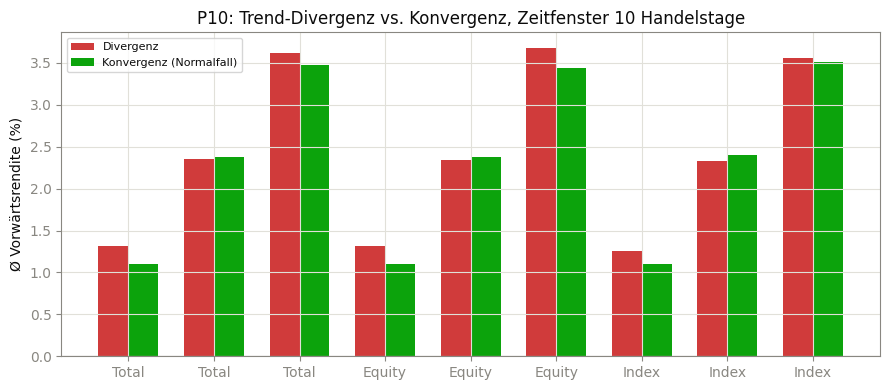

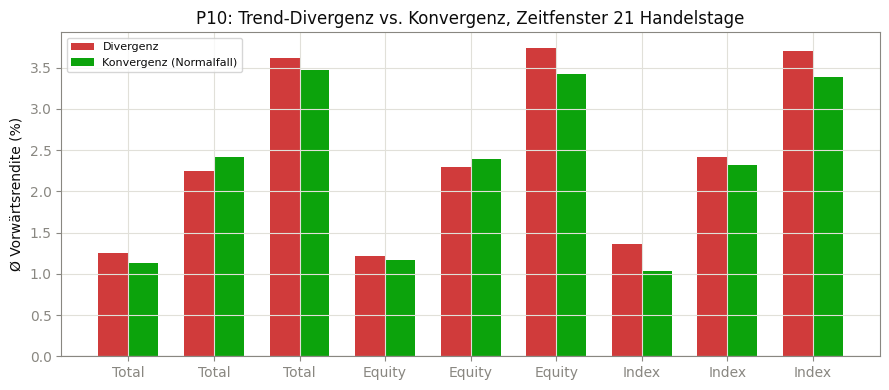

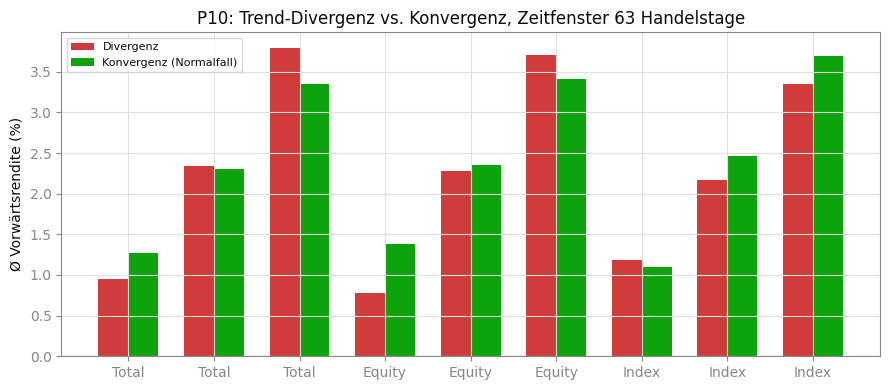

In [28]:
for fenster in TREND_DIVERGENZ_FENSTER:
    teil = tabelle_p10[(tabelle_p10["fenster_tage"] == fenster) & (tabelle_p10["zielgröße"] == "fwd_return")]
    fig, achse = plt.subplots(figsize=(9, 4))
    x = np.arange(len(teil))
    breite = 0.35
    achse.bar(x - breite / 2, teil["mean_a"] * 100, breite, label="Divergenz", color=COLOR_BAD)
    achse.bar(x + breite / 2, teil["mean_b"] * 100, breite, label="Konvergenz (Normalfall)", color=COLOR_GOOD)
    achse.set_xticks(x)
    achse.set_xticklabels(teil["reihe"])
    achse.set_ylabel("\u00d8 90-Tage-Vorwärtsrendite (%)" if False else "\u00d8 Vorwärtsrendite (%)")
    achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
    achse.legend(fontsize=8)
    plt.title(f"P10: Trend-Divergenz vs. Konvergenz, Zeitfenster {fenster} Handelstage")
    plt.tight_layout()
    plt.show()

**Ergebnis:** Die Trend-Divergenz-Hypothese liefert insgesamt nur
schwache Evidenz: Bei den kürzeren Zeitfenstern (10 und 21 Handelstage)
ist keine der 18 Kombinationen signifikant. Erst beim quartalsweisen
Fenster (63 Handelstage) zeigen sich 4 von 18 signifikanten Kombinationen,
durchgehend im Sinne der Hypothese (z. B. Equity/30-Tage-Rendite: 0,8 % bei
Divergenz gegenüber 1,4 % bei Konvergenz). Ein gleichlaufender Trend von
Kurs und PCR scheint damit erst über längere Zeiträume hinweg eine -
schwache - eigenständige Warnwirkung zu entfalten; für die taktischen
Zeitfenster von zwei Wochen bis einem Monat lässt sich die Hypothese in
diesen Daten nicht bestätigen.

### 4.12 Übergreifende Robustheitsübersicht

Fasst über alle getesteten Parametrisierungen je Hypothese den Anteil
signifikanter Kombinationen zusammen - getrennt für Rendite und Risiko.

In [29]:
robustheit = []
for name, tabelle in alle_ergebnisse.items():
    if "zielgröße" not in tabelle.columns:
        continue
    if "signifikant_5pct" in tabelle.columns:
        sig_spalte = "signifikant_5pct"
    elif "kw_signifikant_5pct" in tabelle.columns:
        sig_spalte = "kw_signifikant_5pct"
    else:
        continue
    for ziel in ["fwd_return", "fwd_mdd"]:
        teil = tabelle[tabelle["zielgröße"] == ziel]
        if len(teil) == 0:
            continue
        robustheit.append({
            "hypothese": name, "zielgröße": ziel,
            "getestete_kombinationen": len(teil),
            "anteil_signifikant": teil[sig_spalte].mean(),
        })

tabelle_robustheit = pd.DataFrame(robustheit)
pivot_robustheit = tabelle_robustheit.pivot(index="hypothese", columns="zielgröße", values="anteil_signifikant")
pivot_robustheit = pivot_robustheit.rename(columns={"fwd_return": "Anteil signifikant (Rendite)",
                                                     "fwd_mdd": "Anteil signifikant (Risiko)"})
pivot_robustheit

zielgröße,Anteil signifikant (Risiko),Anteil signifikant (Rendite)
hypothese,,
P10_Trend_Divergenz,0.1111,0.0370
P1_PCR_Extremregime,0.7778,0.7778
P2_PCR_Richtung,0.0000,0.0000
P3_PCR_Quartile,1.0000,1.0000
P4_Angst_Spitze,0.1667,0.1667
P5_Sorglosigkeit_Spitze,0.0000,0.3333
P6_Divergenz_Equity_Index,1.0000,1.0000
P7_Wochentrend_PCR_Extrem,0.1111,0.2222
P8_Intraday_Spike_vs_Bestätigung,0.2222,0.2222


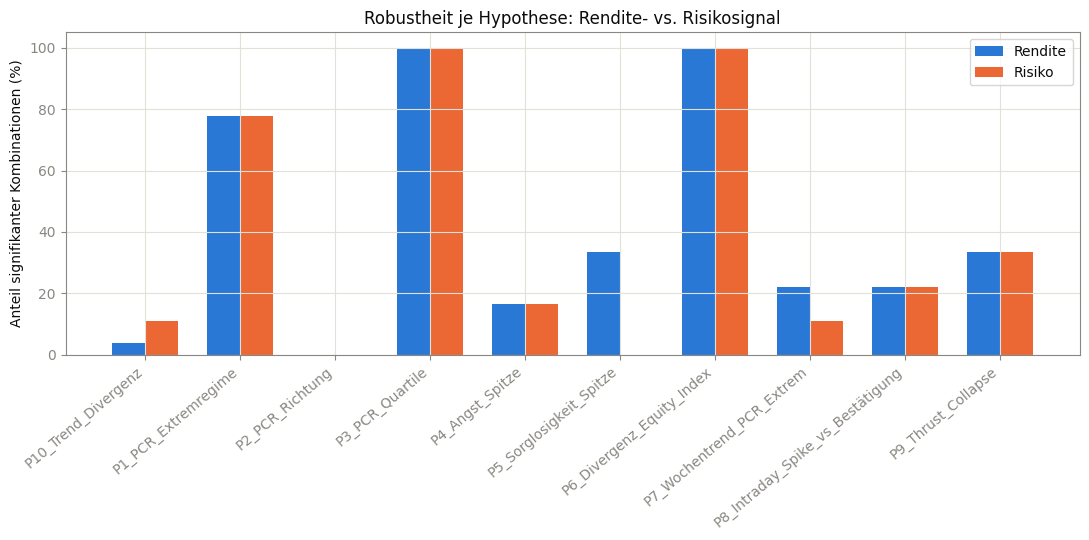

In [30]:
fig, achse = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(pivot_robustheit))
breite = 0.35
achse.bar(x - breite / 2, pivot_robustheit["Anteil signifikant (Rendite)"] * 100, breite, label="Rendite", color=COLOR_A)
achse.bar(x + breite / 2, pivot_robustheit["Anteil signifikant (Risiko)"] * 100, breite, label="Risiko", color=COLOR_B)
achse.set_xticks(x)
achse.set_xticklabels(pivot_robustheit.index, rotation=40, ha="right")
achse.set_ylabel("Anteil signifikanter Kombinationen (%)")
achse.legend()
plt.title("Robustheit je Hypothese: Rendite- vs. Risikosignal")
plt.tight_layout()
plt.show()

**Ergebnis:** Die Robustheitsübersicht bestätigt das Bild aus den
Einzelhypothesen: Am robustesten sind die zustandsbasierten Hypothesen mit
großen Stichproben - P3 (Quartile, 100 %/100 %) und P6 (Divergenz
Equity/Index, 100 %/100 %) sind in jeder getesteten Kombination signifikant,
P1 (Extremregime) in gut drei Vierteln. Die ereignisbasierten
Frühindikatoren (P4, P5, P7) sowie die Richtungs- und
Trend-Divergenz-Hypothesen (P2, P10) liefern dagegen nur vereinzelte oder
gar keine signifikanten Treffer. P8 und P9 liegen dazwischen. Bei P1, P3 und P6 sind Rendite und Risiko
etwa gleich häufig signifikant, was für einen echten, nicht nur risikoseitigen
Kontraindikator-Effekt spricht (zumindest bei der Equity-PCR und der
Equity/Index-Divergenz).

## 5. Einordnung und Handlungsempfehlungen

Die zehn Hypothesen zeichnen ein konsistentes, aber nach PCR-Reihe
deutlich differenziertes Bild. Die **Equity-PCR** verhält sich in
praktisch jeder Parametrisierung (P1, P3, P9) wie ein Lehrbuch-
Kontraindikator: hohe Werte (Angst) gehen mit besserer, niedrige Werte
(Sorglosigkeit) mit schwächerer Folgeperiode einher - sowohl bei der
Rendite als auch beim Risiko. Die **Index-PCR** zeigt dagegen durchgehend
das entgegengesetzte Muster: hohe Werte gehen mit schwächerer Rendite
*und* höherem Risiko einher, verhält sich also eher wie ein koinzidenter
Risikoindikator als wie ein kontrarisches Kaufsignal. Das deckt sich mit
der eingangs beschriebenen These, dass die Index-PCR stark durch
institutionelles Hedging geprägt ist: Institutionen bauen Absicherung
typischerweise auf, *nachdem* sich eine Risikophase bereits abzeichnet,
nicht als antizipatives Signal. Die **Total-PCR** liegt strukturell
dazwischen und liefert dadurch das am wenigsten trennscharfe Bild.

Das mit Abstand robusteste Signal der gesamten Analyse ist nicht das
Niveau einer einzelnen Reihe, sondern die **Divergenz zwischen Equity- und
Index-PCR (P6)**: Laufen Retail- und institutionelles Sentiment auseinander,
ist die Folgeperiode in allen 12 getesteten Kombinationen signifikant
unterschiedlich - deutlich konsistenter als jede Einzelreihe. Die Nutzung
von Intraday-High/Low (P8) liefert ein eigenständiges, wenn auch
schwächeres Zusatzsignal: Ein bis zum Handelsschluss bestätigter
Angst-Ausschlag zeigt ein höheres Folgerisiko als ein untertägig
verpuffter Ausschlag.

**Praxisrelevanz:** Für ein Ampelsystem eignet sich in erster Linie die
Equity-PCR als Niveau-Kennzahl (P1/P3) sowie die Equity-Index-Divergenz
(P6) als zusätzlicher Bestätigungs- bzw. Warnfilter. Die Index-PCR sollte
dagegen nicht isoliert als Kontraindikator verwendet werden, sondern
allenfalls als eigenständiger (koinzidenter) Risikoindikator.

## 6. Ampel-Systematik auf Basis der Put/Call Ratio

### 6.1 Bausteine: PCR-Score (Equity, aus P3) und Drawdown-Stufe

Als Kernbaustein dient die **Equity-PCR**, da sie in P1/P3/P9 durchgehend
als sauberster, korrekt gerichteter Kontraindikator wirkt (siehe Abschnitt
5) - anders als die Index-PCR, die eher koinzident als antizipativ wirkt.
Der **PCR-Score** greift direkt auf die in P3 bereits gebildeten
Equity-Quartile zurück (0 = Q4, höchste Angst/günstig, 2 = Q1, höchste
Sorglosigkeit/ungünstig) und wird mit einer **Drawdown-Stufe** (Abstand des
Index vom bisherigen Hoch) kombiniert.

In [31]:
def pcr_score(quartil: pd.Series) -> pd.Series:
    zuordnung = {QUARTIL_LABELS[3]: 0, QUARTIL_LABELS[2]: 1, QUARTIL_LABELS[1]: 1, QUARTIL_LABELS[0]: 2}
    return quartil.map(zuordnung)


df["PCR_Score"] = pcr_score(df["Quartil_Equity"])

# Drawdown-Stufe (Abstand vom bisherigen Hoch).
df["Allzeithoch"] = df["Close"].cummax()
df["Abstand_vom_Hoch"] = df["Close"] / df["Allzeithoch"] - 1


def drawdown_bucket(x: float) -> str:
    if x >= -0.05:
        return "Nahe am Hoch (0 bis -5%)"
    elif x >= -0.10:
        return "Leichte Korrektur (-5 bis -10%)"
    elif x >= -0.20:
        return "Korrektur (-10 bis -20%)"
    else:
        return "Bärenmarkt (< -20%)"


df["Drawdown_Bucket"] = df["Abstand_vom_Hoch"].apply(drawdown_bucket)
bucket_reihenfolge = ["Nahe am Hoch (0 bis -5%)", "Leichte Korrektur (-5 bis -10%)",
                      "Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)"]

print("Verteilung des PCR-Score (0 = günstig/Angst, 2 = ungünstig/Sorglosigkeit):")
print(df["PCR_Score"].value_counts().sort_index())

Verteilung des PCR-Score (0 = günstig/Angst, 2 = ungünstig/Sorglosigkeit):
PCR_Score
0.0000    1221
1.0000    2442
2.0000    1222
Name: count, dtype: int64


### 6.2 Empirische Grundlage der Kategoriengrenzen

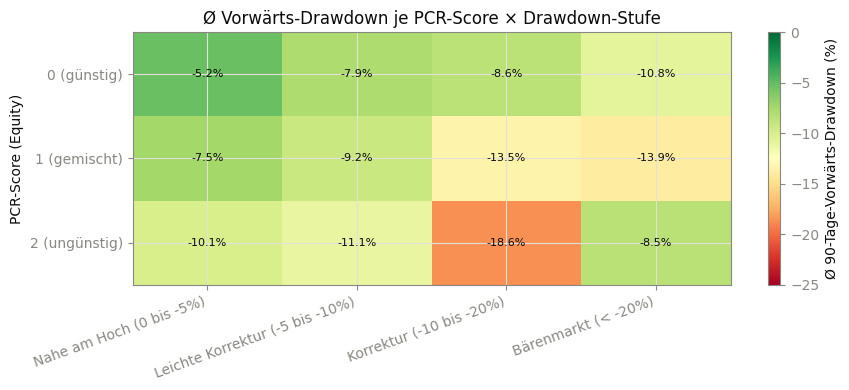

Drawdown_Bucket,Nahe am Hoch (0 bis -5%),Leichte Korrektur (-5 bis -10%),Korrektur (-10 bis -20%),Bärenmarkt (< -20%)
PCR_Score,,,,
0.0000,-0.0520,-0.0792,-0.0858,-0.1081
1.0000,-0.0752,-0.0924,-0.1347,-0.1394
2.0000,-0.1005,-0.1106,-0.1861,-0.0849


In [32]:
heatmap_basis = df.groupby(["PCR_Score", "Drawdown_Bucket"])["fwd_mdd_90d"].mean().unstack()
heatmap_basis = heatmap_basis[bucket_reihenfolge]

fig, achse = plt.subplots(figsize=(9, 4))
bild = achse.imshow(heatmap_basis.values * 100, cmap="RdYlGn", aspect="auto", vmin=-25, vmax=0)
achse.set_xticks(range(len(bucket_reihenfolge)))
achse.set_xticklabels(bucket_reihenfolge, rotation=20, ha="right")
achse.set_yticks(range(3))
achse.set_yticklabels(["0 (günstig)", "1 (gemischt)", "2 (ungünstig)"])
achse.set_ylabel("PCR-Score (Equity)")
for i in range(heatmap_basis.shape[0]):
    for j in range(heatmap_basis.shape[1]):
        wert = heatmap_basis.values[i, j]
        if not np.isnan(wert):
            achse.text(j, i, f"{wert * 100:.1f}%", ha="center", va="center", fontsize=8)
fig.colorbar(bild, ax=achse, label="\u00d8 90-Tage-Vorwärts-Drawdown (%)")
plt.title("\u00d8 Vorwärts-Drawdown je PCR-Score \u00d7 Drawdown-Stufe")
plt.tight_layout()
plt.show()
heatmap_basis

### 6.3 Kategorienregel

In [33]:
def ampel_farbe(score: float, drawdown_bucket: str) -> str:
    günstig = score == 0
    ungünstig = score == 2
    tief = drawdown_bucket in ("Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)")
    flach = drawdown_bucket in ("Nahe am Hoch (0 bis -5%)", "Leichte Korrektur (-5 bis -10%)")

    if günstig and flach:
        return "Grün"
    if ungünstig and tief:
        return "Rot"
    return "Gelb"


df["Ampel"] = [
    ampel_farbe(s, db) if pd.notna(s) else np.nan
    for s, db in zip(df["PCR_Score"], df["Drawdown_Bucket"])
]

print("Verteilung der Handelstage auf die drei Ampelfarben:")
print(df["Ampel"].value_counts().reindex(["Grün", "Gelb", "Rot"]))

Verteilung der Handelstage auf die drei Ampelfarben:
Ampel
Grün     693
Gelb    3965
Rot      227
Name: count, dtype: int64


### 6.4 Statistische Validierung der Ampelfarben

In [34]:
ampel_farben = ["Grün", "Gelb", "Rot"]
ampel_paare = [("Grün", "Gelb"), ("Gelb", "Rot"), ("Grün", "Rot")]

ergebnisse_ampel = []
for a, b in ampel_paare:
    maske_a = df["Ampel"] == a
    maske_b = df["Ampel"] == b
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[maske_a, f"{ziel}_{h}d"], df.loc[maske_b, f"{ziel}_{h}d"],
                label_a=a, label_b=b,
            )
            if res:
                res.update({"vergleich": f"{a} vs. {b}", "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_ampel.append(res)

tabelle_ampel = ergebnisse_zu_tabelle(ergebnisse_ampel)
tabelle_ampel[["vergleich", "horizont_tage", "zielgröße", "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]]

,vergleich,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Grün vs. Gelb,30,fwd_return,0.0207,0.0102,0.0000,0.0000,True
1,Grün vs. Gelb,30,fwd_mdd,-0.0366,-0.0535,0.0000,0.0000,True
2,Grün vs. Gelb,60,fwd_return,0.0410,0.0195,0.0000,0.0000,True
3,Grün vs. Gelb,60,fwd_mdd,-0.0509,-0.0797,0.0000,0.0000,True
4,Grün vs. Gelb,90,fwd_return,0.0619,0.0294,0.0000,0.0000,True
5,Grün vs. Gelb,90,fwd_mdd,-0.0594,-0.0993,0.0000,0.0000,True
6,Gelb vs. Rot,30,fwd_return,0.0102,0.0103,0.9931,0.4243,False
7,Gelb vs. Rot,30,fwd_mdd,-0.0535,-0.0597,0.0168,0.0000,True
8,Gelb vs. Rot,60,fwd_return,0.0195,0.0416,0.0000,0.0000,True
9,Gelb vs. Rot,60,fwd_mdd,-0.0797,-0.0825,0.4583,0.0000,False


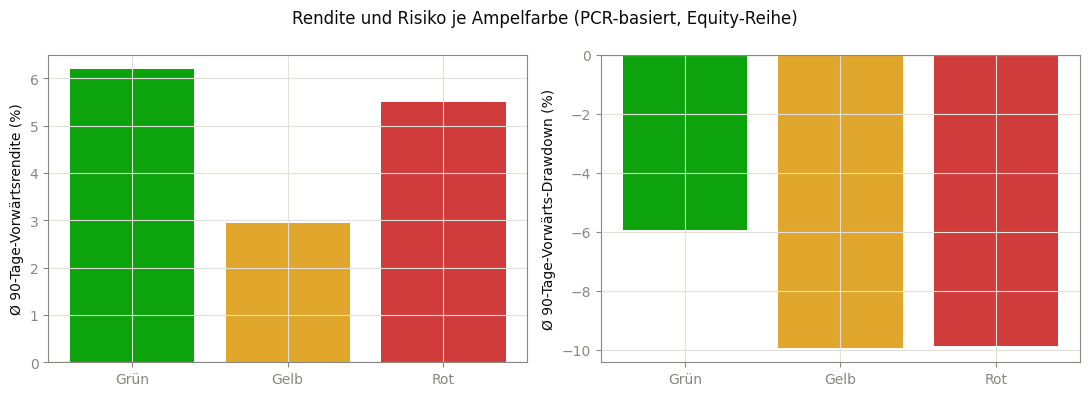

In [35]:
mittelwerte_ampel = df.groupby("Ampel")[["fwd_return_90d", "fwd_mdd_90d"]].mean().reindex(ampel_farben)
ampel_farbcodes = {"Grün": COLOR_GOOD, "Gelb": COLOR_WARN, "Rot": COLOR_BAD}

fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
for achse, spalte, titel in zip(achsen, ["fwd_return_90d", "fwd_mdd_90d"],
                                 ["\u00d8 90-Tage-Vorwärtsrendite", "\u00d8 90-Tage-Vorwärts-Drawdown"]):
    achse.bar(mittelwerte_ampel.index, mittelwerte_ampel[spalte] * 100,
              color=[ampel_farbcodes[f] for f in mittelwerte_ampel.index])
    achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
    achse.set_ylabel(f"{titel} (%)")
fig.suptitle("Rendite und Risiko je Ampelfarbe (PCR-basiert, Equity-Reihe)")
fig.tight_layout()
plt.show()

**Ergebnis:** Grün unterscheidet sich klar und in allen sechs
Kombinationen signifikant von Gelb - höhere Rendite (z. B. 90 Tage: 6,2 %
gegenüber 2,9 %) und geringeres Risiko (90-Tage-Drawdown -5,9 % gegenüber
-9,9 %). Zwischen Gelb und Rot sowie zwischen Grün und Rot zeigt sich
dagegen kein sauberes drittes Stufenbild: Bei der Rendite liegt Rot bei 60
und 90 Tagen sogar signifikant *über* Gelb (90 Tage: 5,5 % gegenüber
2,9 %) und unterscheidet sich nicht signifikant von Grün. Beim Risiko ist
Rot durchgehend signifikant schlechter als Grün, aber gegenüber Gelb nur
beim kürzesten Horizont. Die rein auf der Equity-PCR basierende Ampel
trennt damit zuverlässig "gut" (Grün)
von "durchschnittlich/schlecht" (Gelb/Rot), erreicht aber keine saubere
dritte Risikostufe: Die seltenen Rot-Tage (4,6 %, PCR-Score 2 und tiefer
Drawdown gleichzeitig) fallen historisch offenbar oft in bereits
fortgeschrittene, PCR-seitig schon wieder beruhigte Korrekturphasen nahe an
Wendepunkten - was die Folgerendite in diesen Phasen eher stützt, statt sie
zu belasten.

### 6.5 Ampel-Hintergrund im Kursverlauf

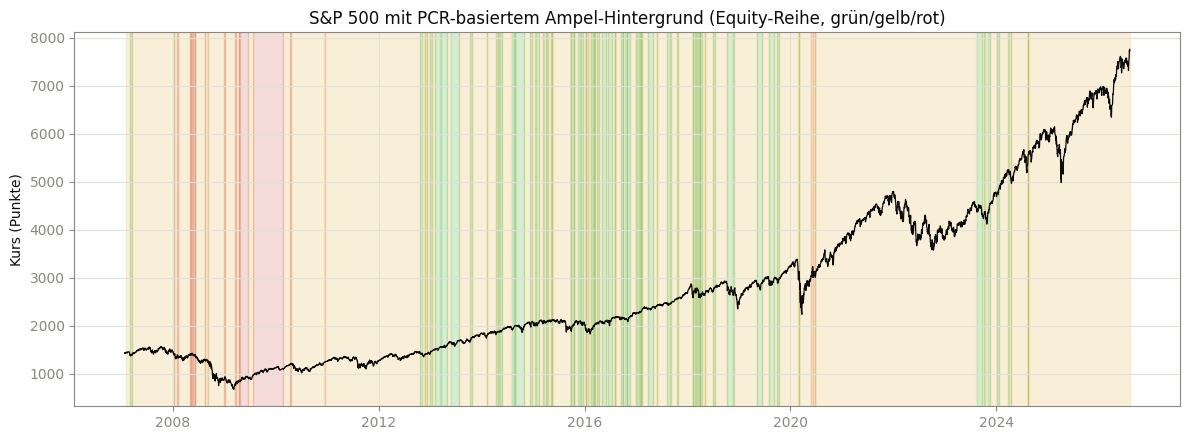

In [36]:
fig, achse = plt.subplots(figsize=(12, 4.5))
for farbe in ampel_farben:
    maske = df["Ampel"] == farbe
    achse.fill_between(df.index, 0, 1, where=maske, color=ampel_farbcodes[farbe], alpha=0.18,
                        transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title(f"{INDEX_NAME} mit PCR-basiertem Ampel-Hintergrund (Equity-Reihe, grün/gelb/rot)")
fig.tight_layout()
plt.show()

## 7. Was-wäre-wenn-Analyse: Wirkung des Risikophasen-Ausschlusses

Für jede Hypothese, bei der sich ein **anhaltender** Regimezustand
definieren lässt (im Unterschied zu den punktuellen Ereignishypothesen),
wird simuliert, wie sich Gesamtrendite, annualisierte Rendite (CAGR) und
maximaler Drawdown verändert hätten, wäre an Tagen mit dem jeweils
ungünstigeren Regimezustand nicht investiert gewesen.

**Methodische Abgrenzung:** Es wird ausschließlich der zum jeweiligen
Zeitpunkt bereits bekannte Regimezustand verwendet (kein Rückschaufehler).
Transaktionskosten und eine Verzinsung der Cash-Position an ausgeschlossenen
Tagen werden nicht berücksichtigt.

**P2, P4, P5, P7, P8, P9 und P10 werden bewusst ausgeschlossen:** punktuelle
Ereignisse, eine Richtungsgröße oder tagesbezogene OHLC-Ausprägungen ohne
anhaltenden Regimezustand - daraus lässt sich keine über mehrere Tage
ausschließbare Phase ableiten. Einbezogen werden P1 (Extremregime, unteres
Dezil je Reihe als Risikostufe), P3 (unteres Quartil je Reihe), P6
(Divergenz A als Risikostufe) sowie die kombinierte Ampel aus Abschnitt 6.

### 7.1 Backtest-Hilfsfunktionen

In [37]:
def historischer_max_drawdown(werte: pd.Series) -> float:
    laufendes_hoch = werte.cummax()
    return (werte / laufendes_hoch - 1).min()


def was_wäre_wenn(schlecht: pd.Series, label: str) -> dict:
    tagesrendite = df["Close"].pct_change().fillna(0)
    schlecht_bereinigt = schlecht.reindex(df.index).fillna(False)

    strategie_rendite = tagesrendite.where(~schlecht_bereinigt, 0)
    equity_buy_hold = (1 + tagesrendite).cumprod()
    equity_strategie = (1 + strategie_rendite).cumprod()

    jahre = (df.index[-1] - df.index[0]).days / 365.25

    def kennzahlen(equity: pd.Series) -> tuple[float, float, float]:
        gesamtrendite = equity.iloc[-1] - 1
        cagr = equity.iloc[-1] ** (1 / jahre) - 1
        mdd = historischer_max_drawdown(equity)
        return gesamtrendite, cagr, mdd

    gr_bh, cagr_bh, mdd_bh = kennzahlen(equity_buy_hold)
    gr_st, cagr_st, mdd_st = kennzahlen(equity_strategie)

    return {
        "hypothese": label,
        "anteil_schlecht_tage": schlecht_bereinigt.mean(),
        "gesamtrendite_buy_hold": gr_bh, "cagr_buy_hold": cagr_bh, "max_drawdown_buy_hold": mdd_bh,
        "gesamtrendite_strategie": gr_st, "cagr_strategie": cagr_st, "max_drawdown_strategie": mdd_st,
        "equity_buy_hold": equity_buy_hold, "equity_strategie": equity_strategie,
    }


print("Backtest-Hilfsfunktionen definiert.")

Backtest-Hilfsfunktionen definiert.


### 7.2 Regime-Definitionen je Hypothese

In [38]:
regime_definitionen: dict[str, pd.Series] = {}

for reihe in PCR_SERIES:
    _, unten = pcr_extremregime(reihe)
    regime_definitionen[f"P1_{reihe}_Sorglosigkeit"] = unten.reindex(df.index).fillna(False)

for reihe in PCR_SERIES:
    regime_definitionen[f"P3_{reihe}_Q1"] = df[f"Quartil_{reihe}"] == QUARTIL_LABELS[0]

regime_definitionen["P6_Divergenz_A_Retail_sorglos"] = divergenz_a.reindex(df.index).fillna(False)

regime_definitionen["Ampel_Rot"] = df["Ampel"] == "Rot"

print("Regime-Definitionen für die Was-wäre-wenn-Analyse:", list(regime_definitionen.keys()))

Regime-Definitionen für die Was-wäre-wenn-Analyse: ['P1_Total_Sorglosigkeit', 'P1_Equity_Sorglosigkeit', 'P1_Index_Sorglosigkeit', 'P3_Total_Q1', 'P3_Equity_Q1', 'P3_Index_Q1', 'P6_Divergenz_A_Retail_sorglos', 'Ampel_Rot']


### 7.3 Konsolidierte Kennzahlenübersicht

In [39]:
ergebnisse_www = [was_wäre_wenn(schlecht, name) for name, schlecht in regime_definitionen.items()]
tabelle_was_wäre_wenn = pd.DataFrame(ergebnisse_www).drop(columns=["equity_buy_hold", "equity_strategie"])
tabelle_was_wäre_wenn

,hypothese,anteil_schlecht_tage,gesamtrendite_buy_hold,cagr_buy_hold,max_drawdown_buy_hold,gesamtrendite_strategie,cagr_strategie,max_drawdown_strategie
0,P1_Total_Sorglosigkeit,0.0999,4.4326,0.0905,-0.5678,2.6088,0.0679,-0.5684
1,P1_Equity_Sorglosigkeit,0.0999,4.4326,0.0905,-0.5678,3.6879,0.0823,-0.5624
2,P1_Index_Sorglosigkeit,0.0999,4.4326,0.0905,-0.5678,3.1014,0.0749,-0.5678
3,P3_Total_Q1,0.2497,4.4326,0.0905,-0.5678,0.9971,0.0360,-0.5644
4,P3_Equity_Q1,0.2497,4.4326,0.0905,-0.5678,1.4625,0.0472,-0.5443
5,P3_Index_Q1,0.2499,4.4326,0.0905,-0.5678,1.7738,0.0536,-0.5434
6,P6_Divergenz_A_Retail_sorglos,0.1962,4.4326,0.0905,-0.5678,2.3927,0.0645,-0.5452
7,Ampel_Rot,0.0464,4.4326,0.0905,-0.5678,3.5408,0.0805,-0.5526


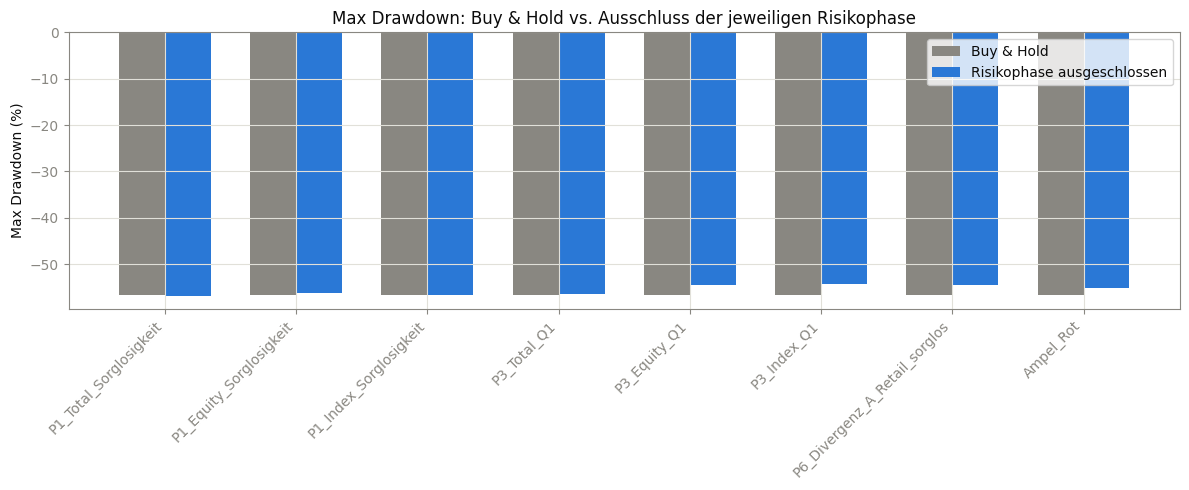

In [40]:
fig, achse = plt.subplots(figsize=(12, 5))
x = np.arange(len(tabelle_was_wäre_wenn))
breite = 0.35
achse.bar(x - breite / 2, tabelle_was_wäre_wenn["max_drawdown_buy_hold"] * 100, breite,
          label="Buy & Hold", color=COLOR_MUTED)
achse.bar(x + breite / 2, tabelle_was_wäre_wenn["max_drawdown_strategie"] * 100, breite,
          label="Risikophase ausgeschlossen", color=COLOR_A)
achse.set_xticks(x)
achse.set_xticklabels(tabelle_was_wäre_wenn["hypothese"], rotation=45, ha="right")
achse.set_ylabel("Max Drawdown (%)")
achse.legend()
plt.title("Max Drawdown: Buy & Hold vs. Ausschluss der jeweiligen Risikophase")
plt.tight_layout()
plt.show()

**Ergebnis:** Der Ausschluss keiner der acht Risikophasen-Definitionen
verbessert das Rendite-Risiko-Profil spürbar: Buy & Hold erzielt seit 2007 eine CAGR von 9,0 % bei einem
Max Drawdown von -56,8 %. Alle acht Varianten senken die CAGR (am
stärksten P3_Total_Q1 auf 3,6 % und P3_Equity_Q1 auf 4,7 %, am
moderatesten Ampel_Rot auf 8,1 % und P1_Equity_Sorglosigkeit auf 8,2 %),
während sich der Max Drawdown in keinem Fall nennenswert verbessert
(bestenfalls von -56,8 % auf -54,3 % bei P3_Index_Q1).

**Wichtiger Vorbehalt:** Dieses Ergebnis steht scheinbar im Widerspruch zu
den in P1/P3 gefundenen, statistisch signifikanten Unterschieden der
*durchschnittlichen* Vorwärtsrendite. Der Unterschied liegt in der
Methodik: P1/P3 messen den Mittelwert überlappender Vorwärtsfenster je
Beobachtungstag, während die Was-wäre-wenn-Simulation eine einzelne,
seriell korrelierte Kapitalkurve fortschreibt. Da die "schlechten"
PCR-Regime historisch in längeren, zusammenhängenden Blöcken auftreten
(z. B. 2008/2009, 2020, 2022) und ausgerechnet diese Blöcke auch einen Teil
der stärksten Erholungstage enthalten, zerstört ein Ausschluss ganzer
Blöcke einen Teil des Zinseszinseffekts, den die reine
Durchschnittsbetrachtung nicht abbildet. Die PCR-Level-Signale sind damit
statistisch real, lassen sich hier aber nicht unmittelbar in eine
profitable Tag-für-Tag-Ausschlussstrategie übersetzen.

### 7.4 Vertiefte Einzelbetrachtung

Für die kombinierte Ampel (Rot-Phasen) wird zusätzlich der zeitliche
Verlauf dargestellt: oben der Kursverlauf mit rot hinterlegter
Ausschlussphase, darunter die Wertentwicklung von Buy & Hold gegenüber der
Ausschluss-Strategie (logarithmische Skala, Startwert = 1).

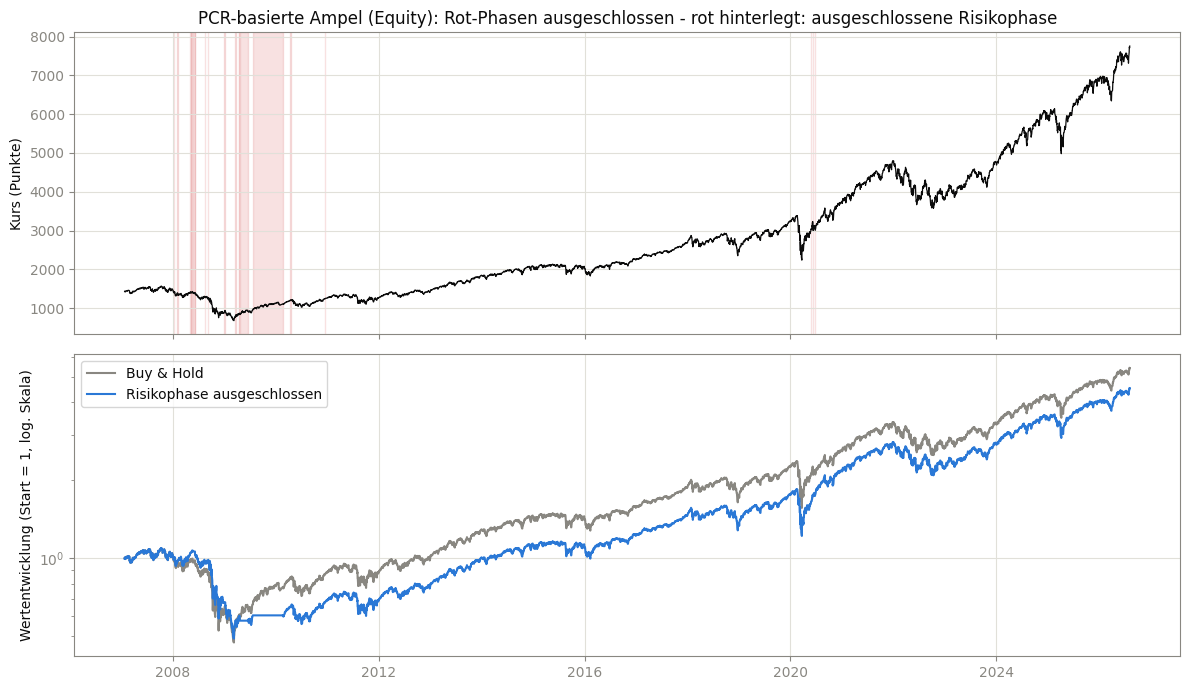

Anteil ausgeschlossener Handelstage: 4.6%
Gesamtrendite  - Buy & Hold: 443.3% | Ausschluss: 354.1%
CAGR           - Buy & Hold: 9.0% | Ausschluss: 8.1%
Max Drawdown   - Buy & Hold: -56.8% | Ausschluss: -55.3%


In [41]:
def plotte_was_wäre_wenn(name: str, schlecht: pd.Series, titel: str) -> dict:
    ergebnis = was_wäre_wenn(schlecht, name)
    schlecht_reindiziert = schlecht.reindex(df.index).fillna(False)

    fig, (achse_kurs, achse_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    achse_kurs.fill_between(df.index, 0, 1, where=schlecht_reindiziert, color=COLOR_BAD, alpha=0.15,
                             transform=achse_kurs.get_xaxis_transform())
    achse_kurs.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
    achse_kurs.set_ylabel("Kurs (Punkte)")
    achse_kurs.set_title(f"{titel} - rot hinterlegt: ausgeschlossene Risikophase")

    achse_equity.plot(df.index, ergebnis["equity_buy_hold"], color=COLOR_MUTED, label="Buy & Hold")
    achse_equity.plot(df.index, ergebnis["equity_strategie"], color=COLOR_A, label="Risikophase ausgeschlossen")
    achse_equity.set_yscale("log")
    achse_equity.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
    achse_equity.legend()

    fig.tight_layout()
    plt.show()

    print(f"Anteil ausgeschlossener Handelstage: {ergebnis['anteil_schlecht_tage']:.1%}")
    print(f"Gesamtrendite  - Buy & Hold: {ergebnis['gesamtrendite_buy_hold']:.1%} | Ausschluss: {ergebnis['gesamtrendite_strategie']:.1%}")
    print(f"CAGR           - Buy & Hold: {ergebnis['cagr_buy_hold']:.1%} | Ausschluss: {ergebnis['cagr_strategie']:.1%}")
    print(f"Max Drawdown   - Buy & Hold: {ergebnis['max_drawdown_buy_hold']:.1%} | Ausschluss: {ergebnis['max_drawdown_strategie']:.1%}")
    return ergebnis


_ = plotte_was_wäre_wenn("Ampel_Rot", regime_definitionen["Ampel_Rot"], "PCR-basierte Ampel (Equity): Rot-Phasen ausgeschlossen")

**Ergebnis:** Der Ausschluss der 4,6 % Rot-Handelstage verändert das
Bild kaum: Die Gesamtrendite sinkt von 443 % (Buy & Hold) auf 354 %, die
CAGR von 9,0 % auf 8,1 %, der Max Drawdown verbessert sich nur marginal von
-56,8 % auf -55,3 %. Das bestätigt den Befund aus 6.4: Die
Equity-PCR-basierte Ampel ist als Timing-Signal für eine einfache
Ausschlussstrategie in dieser Form nicht geeignet - ihr Mehrwert liegt,
wenn überhaupt, im Vergleich Grün gegen Gelb, nicht in der Identifikation
einer eigenständigen Hochrisikophase.

## 8. Export der Ergebnisse

In [42]:
INDEX_DATEINAME = "PCR"

xlsx_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_hypothesenanalysen.xlsx"
with pd.ExcelWriter(xlsx_pfad, engine="openpyxl") as writer:
    for name, tabelle in alle_ergebnisse.items():
        if tabelle is not None and len(tabelle) > 0:
            tabelle.to_excel(writer, sheet_name=name[:31], index=False)
    tabelle_robustheit.to_excel(writer, sheet_name="Robustheit_Übersicht", index=False)
    tabelle_ampel.to_excel(writer, sheet_name="Ampel_Validierung", index=False)
    tabelle_was_wäre_wenn.to_excel(writer, sheet_name="Was_wäre_wenn", index=False)

csv_dateien = []
for name, tabelle in alle_ergebnisse.items():
    if tabelle is None or len(tabelle) == 0:
        continue
    csv_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_{name}.csv"
    tabelle.to_csv(csv_pfad, index=False)
    csv_dateien.append(csv_pfad.name)

robustheit_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Robustheit_Übersicht.csv"
tabelle_robustheit.to_csv(robustheit_csv, index=False)
csv_dateien.append(robustheit_csv.name)

ampel_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Ampel_Validierung.csv"
tabelle_ampel.to_csv(ampel_csv, index=False)
csv_dateien.append(ampel_csv.name)

was_wäre_wenn_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Was_wäre_wenn.csv"
tabelle_was_wäre_wenn.to_csv(was_wäre_wenn_csv, index=False)
csv_dateien.append(was_wäre_wenn_csv.name)

print(f"Excel-Arbeitsmappe gespeichert: {xlsx_pfad}")
print("Einzel-CSV-Dateien gespeichert:")
for f in csv_dateien:
    print(" -", f)

Excel-Arbeitsmappe gespeichert: Hypothesenanalysen\PCR_hypothesenanalysen.xlsx
Einzel-CSV-Dateien gespeichert:
 - PCR_P1_PCR_Extremregime.csv
 - PCR_P2_PCR_Richtung.csv
 - PCR_P3_PCR_Quartile.csv
 - PCR_P4_Angst_Spitze_Index_einzel.csv
 - PCR_P4_Angst_Spitze.csv
 - PCR_P5_Sorglosigkeit_Spitze.csv
 - PCR_P6_Divergenz_Equity_Index.csv
 - PCR_P7_Total_Trend_negativ_PCR_Sorglos_einzel.csv
 - PCR_P7_Equity_Trend_negativ_PCR_Sorglos_einzel.csv
 - PCR_P7_Index_Trend_negativ_PCR_Sorglos_einzel.csv
 - PCR_P7_Wochentrend_PCR_Extrem.csv
 - PCR_P8_Intraday_Spike_vs_Bestätigung.csv
 - PCR_P9_Thrust_Collapse.csv
 - PCR_P10_Trend_Divergenz.csv
 - PCR_Robustheit_Übersicht.csv
 - PCR_Ampel_Validierung.csv
 - PCR_Was_wäre_wenn.csv


## 9. Zusammenfassung

Diese Analyse untersucht, ob die Cboe Put/Call Ratio (Equity, Index,
Total) eine eigenständige, statistisch prüfbare Aussagekraft für die
Rendite- und Risikoentwicklung des S&P 500 besitzt. Datengrundlage sind
tägliche TradingView-OHLC-Exporte der drei Reihen (2007-2026, Total bereits
ab 2006) sowie die bereits bereinigten Kurs- und SMA-Daten des Index.

**Kernbefunde:**

- Die **Equity-PCR** verhält sich über mehrere Hypothesen hinweg (P1, P3,
  P9) konsistent wie ein klassischer Kontraindikator: hohe Werte (Angst)
  gehen mit höherer Rendite und geringerem Risiko der Folgeperiode einher,
  niedrige Werte (Sorglosigkeit) mit dem Gegenteil - der Q1-zu-Q4-Gradient
  in P3 ist sauber monoton.
- Die **Index-PCR** zeigt in denselben Hypothesen (P1, P3, P9) ein
  durchgehend *entgegengesetztes* Bild: hohe Werte gehen mit schwächerer
  Rendite *und* höherem Risiko einher - sie wirkt eher als koinzidenter
  Risikoindikator (institutionelles Hedging fällt zeitlich mit, nicht vor,
  Risikophasen zusammen) denn als kontrarisches Signal.
- Das robusteste Einzelergebnis der gesamten Analyse ist die **Divergenz
  zwischen Equity- und Index-PCR (P6)**: In allen 12 getesteten
  Kombinationen trennt sie die Folgeperiode signifikant - deutlich
  konsistenter als das Niveau jeder Reihe für sich.
- Die **Intraday-Spanne (High/Low, P8)** liefert ein eigenständiges, wenn
  auch schwächeres Zusatzsignal: Ein bis zum Handelsschluss bestätigtes
  PCR-Extrem zeigt tendenziell höheres Folgerisiko als ein untertägig
  verpuffter Ausschlag.
- Richtungs-, Frühindikator- und Trend-Divergenz-Hypothesen (P2, P4, P5,
  P7, P10) liefern dagegen kein robustes Signal - das reine Niveau einer
  Kennzahl scheint aussagekräftiger zu sein als ihre kurzfristige Dynamik.
- Die auf der Equity-PCR aufgebaute **Ampel-Systematik** (Kapitel 6) trennt
  Grün sauber von Gelb, erreicht aber keine belastbare dritte Risikostufe
  (Rot zeigt keine durchgehend schlechtere Rendite als Gelb). In der
  **Was-wäre-wenn-Analyse** (Kapitel 7) verbessert der Ausschluss keiner
  der acht getesteten Risikophasen das Rendite-Risiko-Profil gegenüber
  Buy & Hold spürbar - vermutlich zurückzuführen auf die oben erläuterte
  Diskrepanz zwischen überlappenden Durchschnittsrenditen und einer
  seriell korrelierten Kapitalkurve.

**Übergreifende Einordnung:** Die Put/Call Ratio trägt in dieser Analyse
vor allem über den Reihenvergleich (Equity vs. Index, insbesondere deren
Divergenz) eigenständige Information - stärker als über das Niveau einer
einzelnen Reihe allein und deutlich stärker als über kurzfristige
Ereignis- oder Richtungssignale. Für ein praktisches Ampelsystem eignet
sich die Equity-PCR und die Equity-Index-Divergenz eher als zusätzlicher
Bestätigungsfilter neben anderen Frühindikatoren denn als eigenständiges
Timing-Signal für eine Tag-für-Tag-Ausschlussstrategie.